# Preprocesamiento, Análisis Exploratorio y Entrenamiento de Modelos

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 0–2 | Instalación, importaciones y parámetros globales |
| 3–6 | Carga, corrección de año, fusión LB × V-Dem, exclusiones |
| 7–8 | Recodificación del target y transformaciones de escala |
| **EDA Parte 1** | Exploración sobre datos transformados pre-split |
| 9–10 | Definición de features y construcción de splits temporales |
| **EDA Parte 2** | Validación post-transformación y selección empírica de features |
| 11–12 | Imputación diferenciada y función de evaluación |
| 13–17 | Cinco modelos con optimización Optuna |
| 18 | Ciclo principal de entrenamiento y guardado del pipeline completo |
| 19–21 | Función de predicción en producción, resultados y visualización |
| 22 | Registro de versiones |

> **Regla de oro anti-data leakage:** toda transformación aprendida (imputador, scaler)
> se ajusta **exclusivamente** sobre el conjunto de entrenamiento de cada split.

## 1. Importaciones

In [1]:
# =============================================================================
# Importaciones globales
# =============================================================================
import os, gc, json, joblib, warnings, logging
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno

from sklearn.experimental import enable_iterative_imputer   # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, cohen_kappa_score,
    roc_auc_score, mean_absolute_error,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from tqdm.notebook import tqdm

# Agregar raiz del proyecto al path (funciona en VS Code y Jupyter Lab)
import sys

_root = Path(".").resolve()
if not (_root / "utils").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("✓ Importaciones completadas.")

✓ Importaciones completadas.


/home/mporras/DemocraticSatisfactionLatam/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuraciones personalizadas

In [2]:
from utils.config import (
    SPLIT, PAISES_EXCLUIR_EVAL, AÑO_CORTE_VEN,
    setup_plots, THEME, PALETTES, PARAMETERS, PATHS,
    MAPEO_NUMINVES, MAPEO_PAIS_ISO3,
    COL_TARGET, COL_AÑO, COL_PAIS, COL_ISO3, COL_PESO, NSNR,
    VARS_EXCLUIR_LB, VARS_EXCLUIR_VDEM,
    VARS_CATEGORICAS, N_CLASES, ETIQUETAS, BLOQUES, ETIQUETAS_FEATURES,
    bloque_de,
)
from utils.plots import save_figure, model_color
from utils.preprocessing import (
    limpiar_nsnr, construir_split, resumen_split, imputar, normalizar,
    aplicar_transformaciones_deterministas,
)
from utils.metrics import evaluar
from utils.models import (
    entrenar_olo, entrenar_xgboost, entrenar_catboost,
    entrenar_lightgbm, entrenar_tabnet, entrenar_ridge, predecir,
)
setup_plots()
print("✓ Utils importados correctamente.")

✓ Utils importados correctamente.


## 2. Parámetros globales del pipeline

> Toda configuración ajustable se concentra aquí.
> Modificar este bloque sin tocar el resto del notebook.

In [3]:
# =============================================================================
# PARÁMETROS GLOBALES — solo configuración de ejecución y hardware
# =============================================================================

np.random.seed(PARAMETERS["SEED"])
torch.manual_seed(PARAMETERS["SEED"])

# ── Hardware ───────────────────────────────────────────────────────────────────
USAR_GPU       = True
DEVICE_CUDA    = "gpu"
DISPOSITIVO_TN = "cuda" if USAR_GPU and torch.cuda.is_available() else "cpu"
N_JOBS         = -1

# ── Directorios ───────────────────────────────────────────────────────────────
for d in [PATHS["FOLDER_PROCS"], PATHS["FOLDER_MODELS"], PATHS["FOLDER_RESULTS"],
          PATHS["FOLDER_RESULTS_FIGURES"], PATHS["FOLDER_RESULTS_METRICS"],
          PATHS["FOLDER_RESULTS_TABLES"]]:
    d.mkdir(parents=True, exist_ok=True)

# ── Flags de ejecución ────────────────────────────────────────────────────────
EJECUTAR_BUSQUEDA_HP = True   # False carga HPs ya guardados si existen
N_TRIALS_OPTUNA      = 50     # Reducir a 20 para pruebas rápidas

# ── Config de hardware para funciones de entrenamiento ────────────────────────
HW_CFG = {
    "usar_gpu"      : USAR_GPU,
    "device_cuda"   : DEVICE_CUDA,
    "dispositivo_tn": DISPOSITIVO_TN,
    "n_jobs"        : N_JOBS,
    "ejecutar_hp"   : EJECUTAR_BUSQUEDA_HP,
    "n_trials"      : N_TRIALS_OPTUNA,
}

print("✓ Parámetros globales cargados.")
print(f"  GPU disponible : {torch.cuda.is_available()}")
print(f"  Dispositivo    : {DISPOSITIVO_TN}")
print(f"  Semilla        : {PARAMETERS['SEED']}")
print(f"  Bloques temáticos definidos: {len(BLOQUES)}")
print(f"  Variables con etiqueta: {len(ETIQUETAS_FEATURES)}")

✓ Parámetros globales cargados.
  GPU disponible : True
  Dispositivo    : cuda
  Semilla        : 42
  Bloques temáticos definidos: 6
  Variables con etiqueta: 28


In [4]:
torch.cuda.is_available() 

True

## 3. Carga de datos consolidados

In [5]:
# =============================================================================
# Carga de Latinobarómetro y V-Dem
# =============================================================================
print("Cargando Latinobarómetro...")
file_load = PATHS["FILE_BASE_LB_SAMPLE"] if PARAMETERS["LOAD_SAMPLE"] else PATHS["FILE_BASE_LB"]
print(f"  Cargando archivo: {file_load}")
df_lb_raw = pd.read_csv(file_load, low_memory=False, encoding="utf-8-sig")
print(f"  {df_lb_raw.shape[0]:,} registros × {df_lb_raw.shape[1]} columnas")

print("Cargando V-Dem...")
df_vdem_raw = pd.read_csv(PATHS["FILE_BASE_VDEM"], low_memory=False, encoding="utf-8-sig")
print(f"  {df_vdem_raw.shape[0]:,} registros × {df_vdem_raw.shape[1]} columnas")

print()
print("Muestra LB (3 filas, primeras 8 columnas):")
print(df_lb_raw.iloc[:3, :8].to_string())
print()
print("Muestra V-Dem (3 filas):")
print(df_vdem_raw.head(3).to_string())

Cargando Latinobarómetro...
  Cargando archivo: ../data/base/latinobarometro.csv


  489,771 registros × 43 columnas
Cargando V-Dem...
  540 registros × 28 columnas

Muestra LB (3 filas, primeras 8 columnas):
       ola  A_001_001  A_003_021  A_003_031  A_007_001  A_007_071  B_001_101  B_006_061
0  LAT2013        1.0        6.0        2.0        4.0        6.0        1.0        2.0
1  LAT2013        2.0        4.0        3.0        4.0        2.0        1.0        2.0
2  LAT2013        2.0        7.0        3.0        4.0        5.0        1.0        2.0

Muestra V-Dem (3 filas):
  country_name country_text_id  country_id  year  COWcode  v2x_polyarchy  v2x_libdem  v2x_partipdem  v2x_delibdem  v2x_egaldem  v2x_freexp_altinf  v2xcl_rol  v2x_jucon  v2xlg_legcon  v2x_cspart  v2x_egal  v2xeg_eqdr  v2x_accountability_osp  v2xnp_regcorr  v2x_neopat  v2xpe_exlsocgr  v2xpe_exlecon  v2x_corr  v2x_pubcorr  v2x_execorr  v2x_gender  v2x_rule  v2xcs_ccsi
0    Argentina             ARG          37  1995    160.0          0.833       0.641          0.575         0.773        0.657  

## 4. Corrección de la variable año y clave de fusión

`X_002` contiene el año calendario en la mayoría de olas, pero en cinco olas usa
el número de investigación: `16=2011`, `17=2013`, `18=2015`, `23=2023`, `24=2024`.
Esta corrección se aplica como primer paso antes de cualquier otra operación.

In [6]:
# =============================================================================
# Corrección de X_002 → año calendario
# =============================================================================
df_lb = df_lb_raw.copy()

if "ola" in df_lb.columns:
    df_lb[COL_AÑO] = df_lb["ola"].str.replace("LAT", "", regex=False).astype(int)
    print("✓ Año extraído desde columna 'ola'")
else:
    df_lb[COL_AÑO] = df_lb["X_002"].map(
        lambda x: MAPEO_NUMINVES.get(int(x), int(x))
    )
    print("✓ Año derivado de X_002 con corrección de numinves")

print()
print("Distribución de registros por año:")
for año, n in df_lb[COL_AÑO].value_counts().sort_index().items():
    print(f"  {int(año)}: {n:,}")

# Derivar ISO3
if COL_ISO3 not in df_lb.columns:
    print(f"\nDerivando ISO3 desde {COL_PAIS}...")
    df_lb[COL_ISO3] = df_lb[COL_PAIS].map(MAPEO_PAIS_ISO3)

n_sin = df_lb[COL_ISO3].isna().sum()
if n_sin > 0:
    print(f"\n⚠ Países sin ISO3: {df_lb[df_lb[COL_ISO3].isna()][COL_PAIS].unique()}")
else:
    print(f"\n✓ ISO3 derivado sin errores ({df_lb[COL_ISO3].nunique()} países)")

del df_lb_raw
gc.collect()

✓ Año extraído desde columna 'ola'

Distribución de registros por año:
  1995: 9,069
  1996: 21,200
  1997: 20,243
  1998: 20,331
  2000: 18,038
  2001: 20,631
  2002: 21,006
  2003: 21,133
  2004: 22,096
  2005: 20,222
  2006: 22,708
  2007: 22,694
  2008: 22,675
  2009: 22,690
  2010: 22,687
  2011: 20,204
  2013: 22,663
  2015: 20,250
  2016: 20,204
  2017: 20,200
  2018: 20,204
  2020: 20,204
  2023: 19,205
  2024: 19,214

⚠ Países sin ISO3: <ArrowStringArray>
[nan]
Length: 1, dtype: str


27

Eliminar registros sin país

In [7]:
# Eliminar todos los registros que no tengan nombre de país o año, ya que no se pueden usar para entrenamiento ni validación

df_lb = df_lb.dropna(subset=[COL_PAIS, COL_AÑO])


In [8]:
print(f"\nTamaño de la muestra final: {df_lb.shape[0]:,} registros × {df_lb.shape[1]} columnas")


Tamaño de la muestra final: 457,499 registros × 44 columnas


## 5. Fusión Latinobarómetro × V-Dem

In [9]:
# =============================================================================
# Merge LB × V-Dem por clave (pais_iso3, año)
# =============================================================================
df_vdem = df_vdem_raw.copy().rename(
    columns={"country_text_id": COL_ISO3, "year": COL_AÑO}
)
cols_drop = ["country_name", "country_id", "COWcode"] + VARS_EXCLUIR_VDEM
df_vdem   = df_vdem[[c for c in df_vdem.columns if c not in cols_drop]]

n_vdem_feat = len([c for c in df_vdem.columns if c not in [COL_ISO3, COL_AÑO]])
print(f"Variables V-Dem a fusionar: {n_vdem_feat}")

df = df_lb.merge(df_vdem, on=[COL_ISO3, COL_AÑO], how="left", validate="m:1")

n_sin_vdem = df["v2x_polyarchy"].isna().sum()
pct_ok     = (1 - n_sin_vdem / len(df)) * 100
print(f"\nResultado del merge:")
print(f"  Registros totales  : {len(df):,}")
print(f"  Con V-Dem completo : {len(df) - n_sin_vdem:,} ({pct_ok:.1f}%)")
print(f"  Sin V-Dem          : {n_sin_vdem:,}")
print(f"  Columnas totales   : {df.shape[1]}")

# ── Auditoría de cobertura V-Dem ──────────────────────────────────────────────
# Los NaN en índices V-Dem post-merge son Missing Not At Random (MNAR):
# su ausencia refleja que el país no tenía datos institucionales para ese año,
# lo que es en sí mismo información relevante para el análisis.
# Se documentan aquí para justificar el supuesto de imputabilidad.
vdem_cols_check = ["v2x_polyarchy", "v2x_libdem", "v2x_corr"]
vdem_check = [c for c in vdem_cols_check if c in df.columns]
if vdem_check:
    print()
    print("Auditoría de cobertura V-Dem post-merge:")
    sin_vdem = df[df[vdem_check[0]].isna()]
    if len(sin_vdem) > 0:
        print(f"  Registros sin datos V-Dem: {len(sin_vdem):,} ({len(sin_vdem)/len(df)*100:.1f}%)")
        print("  Distribución por país:")
        for pais, n in sin_vdem[COL_PAIS].value_counts().head(10).items():
            print(f"    {pais:<25}: {n:,} registros")
        años_sin = sorted(sin_vdem[COL_AÑO].unique())
        print(f"  Años afectados: {años_sin}")
        print("  Nota: estos NaN se imputarán con MICE para OLO y TabNet.")
        print("        Los modelos de árboles los manejan nativamente.")
    else:
        print("  ✓ Cobertura V-Dem completa para todos los registros.")

del df_lb, df_vdem, df_vdem_raw
gc.collect()

Variables V-Dem a fusionar: 19



Resultado del merge:
  Registros totales  : 457,499
  Con V-Dem completo : 457,499 (100.0%)
  Sin V-Dem          : 0
  Columnas totales   : 63

Auditoría de cobertura V-Dem post-merge:
  ✓ Cobertura V-Dem completa para todos los registros.


0

## 6. Exclusiones iniciales

In [10]:
# =============================================================================
# Exclusiones de variables y registros
# =============================================================================

# Paso 1: variables LB descartadas
excl = [c for c in VARS_EXCLUIR_LB if c in df.columns]
df   = df.drop(columns=excl)
print(f"Variables LB excluidas: {excl}")

# Paso 2: registros sin target válido
mask_inv = df["A_003_031"].isna() | df["A_003_031"].isin(NSNR)
n_inv    = mask_inv.sum()
df       = df[~mask_inv].copy()
print(f"Registros excluidos por target NS/NR: {n_inv:,}")

# Paso 3: Venezuela post-2017
mask_ven = (df[COL_PAIS] == "Venezuela") & (df[COL_AÑO] > AÑO_CORTE_VEN)
n_ven    = mask_ven.sum()
df       = df[~mask_ven].copy()
print(f"Registros Venezuela post-{AÑO_CORTE_VEN} excluidos: {n_ven:,}")

# Paso 4: años fuera del rango del estudio
# años_validos = union de todos los conjuntos del split único
años_validos = set(SPLIT["train"]) | set(SPLIT["val"]) | set(SPLIT["test"])
n_antes = len(df)
df      = df[df[COL_AÑO].isin(años_validos)].copy()
print(f"Registros con año fuera del rango: {n_antes - len(df):,}")

print(f"\nDataset tras exclusiones: {df.shape[0]:,} × {df.shape[1]}")
print(f"Países : {df[COL_PAIS].nunique()}")
print(f"Años   : {sorted(df[COL_AÑO].unique())}")
gc.collect()

Variables LB excluidas: ['C_001_031', 'A_003_021', 'D_001_061', 'D_001_131', 'X_004', 'S_700', 'H_002_101', 'C_003_003_011', 'A_007_071', 'H_001_011', 'S_701', 'X_008']


Registros excluidos por target NS/NR: 21,036
Registros Venezuela post-2017 excluidos: 4,707
Registros con año fuera del rango: 0

Dataset tras exclusiones: 431,756 × 51
Países : 18
Años   : [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2023), np.int64(2024)]


0

## 7. Recodificación de la variable dependiente

In [11]:
# =============================================================================
# Recodificación A_003_031 → target base 0: {0, 1, 2, 3}
# =============================================================================
vals = sorted(df["A_003_031"].dropna().unique())
assert set(int(v) for v in vals) == {1, 2, 3, 4}, f"Escala inesperada: {vals}"

df[COL_TARGET] = df["A_003_031"].map({1.0:0, 2.0:1, 3.0:2, 4.0:3})
assert df[COL_TARGET].isna().sum() == 0, "NaN inesperados en target"

print("Distribución del target recodificado:")
dist = df[COL_TARGET].value_counts().sort_index()
for cls, n in dist.items():
    print(f"  Clase {int(cls)}: {n:>8,} ({n/len(df)*100:.1f}%) — {ETIQUETAS[cls]}")

# Pesos inversos de clase para manejo del desbalance sin SMOTE
PESOS_CLASE = {
    cls: len(df) / (N_CLASES * (df[COL_TARGET] == cls).sum())
    for cls in range(N_CLASES)
}
print("\nPesos inversos de clase:")
for cls, w in PESOS_CLASE.items():
    print(f"  Clase {cls} ({ETIQUETAS[cls]:<25}): {w:.4f}")

Distribución del target recodificado:
  Clase 0:   41,437 (9.6%) — Para nada satisfecho
  Clase 1:  112,974 (26.2%) — No muy satisfecho
  Clase 2:  187,030 (43.3%) — Más bien satisfecho
  Clase 3:   90,315 (20.9%) — Muy satisfecho

Pesos inversos de clase:
  Clase 0 (Para nada satisfecho     ): 2.6049
  Clase 1 (No muy satisfecho        ): 0.9554
  Clase 2 (Más bien satisfecho      ): 0.5771
  Clase 3 (Muy satisfecho           ): 1.1951


## 8. Transformaciones de escala

Se aplica la convención de **mayor valor = más favorable** de forma consistente.
El orden es crítico: NS/NR → NaN primero, luego inversiones, para evitar que
valores especiales generen datos ficticios.

In [12]:
# =============================================================================
# Transformaciones de escala — orden obligatorio
# (limpiar_nsnr importada desde utils.preprocessing)
# =============================================================================

# ── Paso 1: NS/NR → NaN en todas las columnas relevantes ─────────────────────
cols_limpiar = [c for c in df.columns
                if c not in [COL_TARGET, COL_AÑO, COL_PESO,
                              "A_003_031", COL_ISO3, COL_PAIS, "ola"]]
df = limpiar_nsnr(df, cols_limpiar, NSNR)
print("✓ NS/NR → NaN")

# ── Paso 2: Valores especiales adicionales ────────────────────────────────────
print("✓ Valores especiales adicionales")

# Paso 3: inversión de Likert ELIMINADA — no se invierten variables.
# Los modelos de árboles son invariantes a transformaciones monotónicas.
# Ver documento metodológico sección 5.
print("✓ Sin inversiones de escala (diseño adoptado)")

# Paso 4: inversión de interés en política ELIMINADA
# ── Paso 5: Evaluaciones económicas comparativas ──────────────────────────────
for col in ["D_001_021", "D_001_041", "D_001_091"]:
    if col not in df.columns:
        continue
    mask3 = (df[COL_AÑO] <= 2000) & df[col].between(1, 3)
    mask5 = (df[COL_AÑO] >= 2001) & df[col].between(1, 5)
    df.loc[mask3, col] = 4 - df.loc[mask3, col]
    df.loc[mask5, col] = 6 - df.loc[mask5, col]
print("✓ Evaluaciones económicas comparativas armonizadas")

# ── Paso 6: Recodificaciones binarias ─────────────────────────────────────────
# Se usa np.select en lugar de .map() para evitar que valores no contemplados
# se conviertan silenciosamente a NaN. Los valores fuera de {1.0, 2.0} se
# marcan explícitamente como NaN con condición residual documentada.
recodif = {
    "B_006_061": {1.0: 1, 2.0: 0},   # Aprueba=1, Desaprueba=0
    "B_001_101": {1.0: 1, 2.0: 0},   # País para todos=1, para poderosos=0
    "H_001_011": {1.0: 1, 2.0: 0},   # Confianza: Sí=1, No=0
    "S_001"    : {1.0: 0, 2.0: 1},   # Sexo: Hombre=0, Mujer=1
}
for col, mapeo in recodif.items():
    if col not in df.columns:
        continue
    nan_antes = int(df[col].isna().sum())
    condiciones  = [df[col] == k for k in mapeo]
    valores      = list(mapeo.values())
    df[col] = np.select(condiciones, valores, default=np.nan)
    nan_despues = int(df[col].isna().sum())
    delta = nan_despues - nan_antes
    if delta > 0:
        print(f"  ⚠ {col}: {delta} valores no contemplados → NaN (antes: {nan_antes}, después: {nan_despues})")
print(f"✓ Recodificaciones binarias: {list(recodif.keys())}")

# ── Paso 7: Victimización I_001_001 — 3 períodos de codificación ──────────────
if "I_001_001" in df.columns:
    col   = "I_001_001"
    nueva = np.full(len(df), np.nan)
    m_bin  = (df[COL_AÑO] <= 2008).values
    nueva[m_bin & (df[col].values == 1)] = 1
    nueva[m_bin & (df[col].values == 2)] = 0
    m_09   = (df[COL_AÑO] == 2009).values
    nueva[m_09 & np.isin(df[col].values, [1, 2])] = 1
    nueva[m_09 & (df[col].values == 3)]            = 0
    m_post = (df[COL_AÑO] >= 2010).values
    nueva[m_post & np.isin(df[col].values, [1, 2, 3])] = 1
    nueva[m_post & (df[col].values == 4)]               = 0
    df[col] = nueva
print("✓ Victimización recodificada (3 períodos → binaria)")

# ── Paso 8: G_002_011 — corrupción experiencial (LAT2013 con escala anómala) ──
# Olas estándar: 1=Sí conoce, 2=No conoce → recodificar a 1/0.
# LAT2013: escala {1,2,3,4,5} → 1=Sí, >1=No.
# Cualquier valor no contemplado → NaN explícito (evita valores inválidos).
if "G_002_011" in df.columns:
    col = "G_002_011"
    nueva = np.full(len(df), np.nan)
    # Olas estándar (≠ 2013)
    m_std = (df[COL_AÑO] != 2013).values
    nueva[m_std & (df[col].values == 1)] = 1
    nueva[m_std & (df[col].values == 2)] = 0
    # LAT2013
    m_13  = (df[COL_AÑO] == 2013).values
    nueva[m_13 & (df[col].values == 1)] = 1
    nueva[m_13 & (df[col].values >  1) & df[col].notna().values] = 0
    # Conteo de valores residuales que quedan como NaN
    n_residual = int(df[col].notna().sum()) - int(np.sum(nueva == 1) + np.sum(nueva == 0))
    if n_residual > 0:
        print(f"  ⚠ G_002_011: {n_residual} valores residuales → NaN")
    df[col] = nueva
print("✓ Corrupción experiencial recodificada")

# ── Paso 9: V-Dem — índices de corrupción (1 - x) ────────────────────────────
# Inversión V-Dem eliminada — sin inversiones en este diseño
# Inversión V-Dem eliminada — sin inversiones en este diseño
print("  Semántica post-inversión: mayor valor = menor corrupción")

# ── Auditoría de NaN post-transformación ─────────────────────────────────────
# Verificar que no se introdujeron NaN inesperados durante las transformaciones.
# Las variables con NaN esperados son aquellas ausentes en ciertas olas.
print()
print("=" * 55)
print(f"  Dataset final: {df.shape[0]:,} × {df.shape[1]}")
print(f"  Missingness global: {df.isnull().mean().mean()*100:.1f}%")
print()
print("  Variables con >30% de NaN (requieren imputación significativa):")
nan_pct = df.isnull().mean().sort_values(ascending=False)
vars_alta_nan = nan_pct[nan_pct > 0.30]
cols_meta = {COL_AÑO, COL_PAIS, COL_ISO3, COL_PESO, "A_003_031", "ola", COL_TARGET}
vars_alta_nan = vars_alta_nan[~vars_alta_nan.index.isin(cols_meta)]
if vars_alta_nan.empty:
    print("    Ninguna variable supera el 30% de NaN.")
else:
    for col, pct in vars_alta_nan.items():
        print(f"    {col:<25}: {pct*100:.1f}%")

✓ NS/NR → NaN
✓ Valores especiales adicionales
✓ Sin inversiones de escala (diseño adoptado)
✓ Evaluaciones económicas comparativas armonizadas
  ⚠ B_001_101: 67 valores no contemplados → NaN (antes: 141783, después: 141850)
✓ Recodificaciones binarias: ['B_006_061', 'B_001_101', 'H_001_011', 'S_001']
✓ Victimización recodificada (3 períodos → binaria)
✓ Corrupción experiencial recodificada
  Semántica post-inversión: mayor valor = menor corrupción

  Dataset final: 431,756 × 52
  Missingness global: 6.9%

  Variables con >30% de NaN (requieren imputación significativa):
    G_005_001                : 40.8%
    C_006_003_011            : 38.1%
    A_007_001                : 35.9%
    B_001_101                : 32.9%
    G_002_011                : 32.8%


## EDA — Parte 1: Exploración del dataset integrado

Análisis sobre el dataset completo post-transformación y pre-split.
Objetivo: comprender la distribución del target, el patrón de missingness
y las características globales antes de particionar en subperiodos.

  ✓ Figura guardada: eda1_target_subperiodos.png


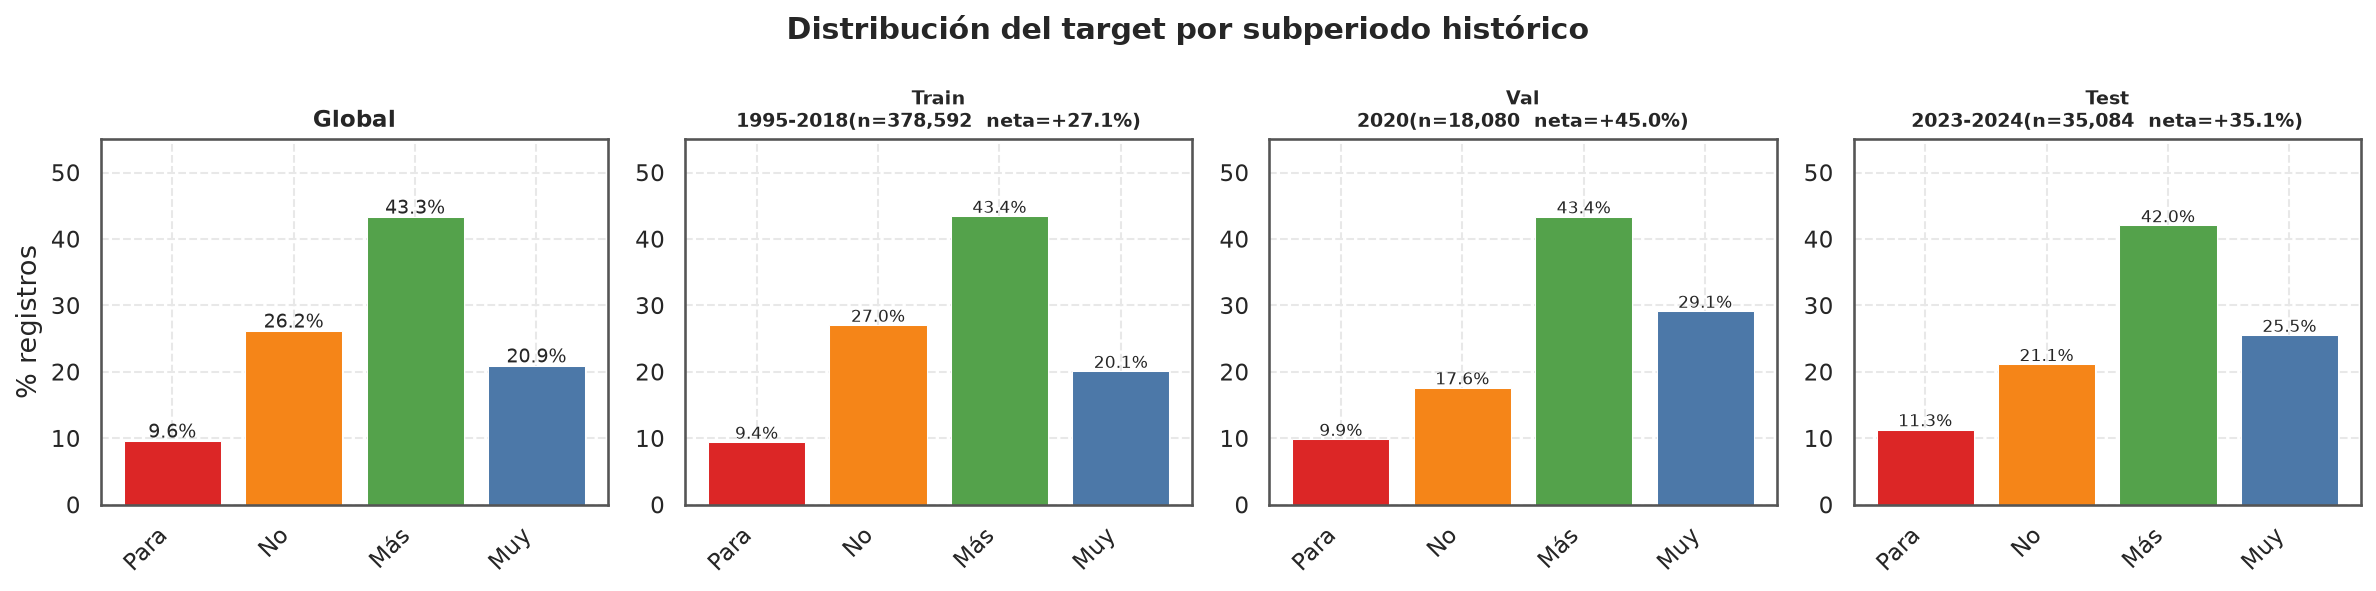

✓ Figura guardada: eda1_target_subperiodos.png


In [13]:
# =============================================================================
# EDA 1.1 — Distribución del target por conjunto (train / val / test)
# =============================================================================
# EDA 1.1 — Split único: Train / Validación / Test
SP_HIST = {
    "Train\n1995-2018": SPLIT["train"],
    "Val\n2020":        SPLIT["val"],
    "Test\n2023-2024":  SPLIT["test"],
}
colores_cls = [THEME["target"][i] for i in range(4)]

fig, axes = plt.subplots(1, len(SP_HIST) + 1, figsize=(16, 4))

# Panel global
ax = axes[0]
vals_g = df[COL_TARGET].value_counts(normalize=True).sort_index() * 100
etiq_cortas = [v.split()[0] for v in ETIQUETAS.values()]
ax.bar(etiq_cortas, vals_g.values, color=colores_cls, edgecolor="white", linewidth=0.5)
ax.set_title("Global", fontweight="bold", fontsize=11)
ax.set_ylabel("% registros")
ax.set_ylim(0, 55)
for i, v in enumerate(vals_g.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# Paneles por subperiodo
for ax, (sp_label, años) in zip(axes[1:], SP_HIST.items()):
    sub  = df[df[COL_AÑO].isin(años)]
    vals = sub[COL_TARGET].value_counts(normalize=True).sort_index() * 100
    neta = (vals.get(2, 0) + vals.get(3, 0)) - (vals.get(0, 0) + vals.get(1, 0))
    bars = [vals.get(i, 0) for i in range(4)]
    ax.bar(etiq_cortas, bars, color=colores_cls, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{sp_label}(n={len(sub):,}  neta={neta:+.1f}%)",
                 fontsize=9, fontweight="bold")
    ax.set_ylim(0, 55)
    for i, v in enumerate(bars):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)

fig.suptitle("Distribución del target por subperiodo histórico", fontweight="bold")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
save_figure("eda1_target_subperiodos")
plt.show()
print("✓ Figura guardada: eda1_target_subperiodos.png")

  ✓ Figura guardada: eda1_missingness_heatmap.png


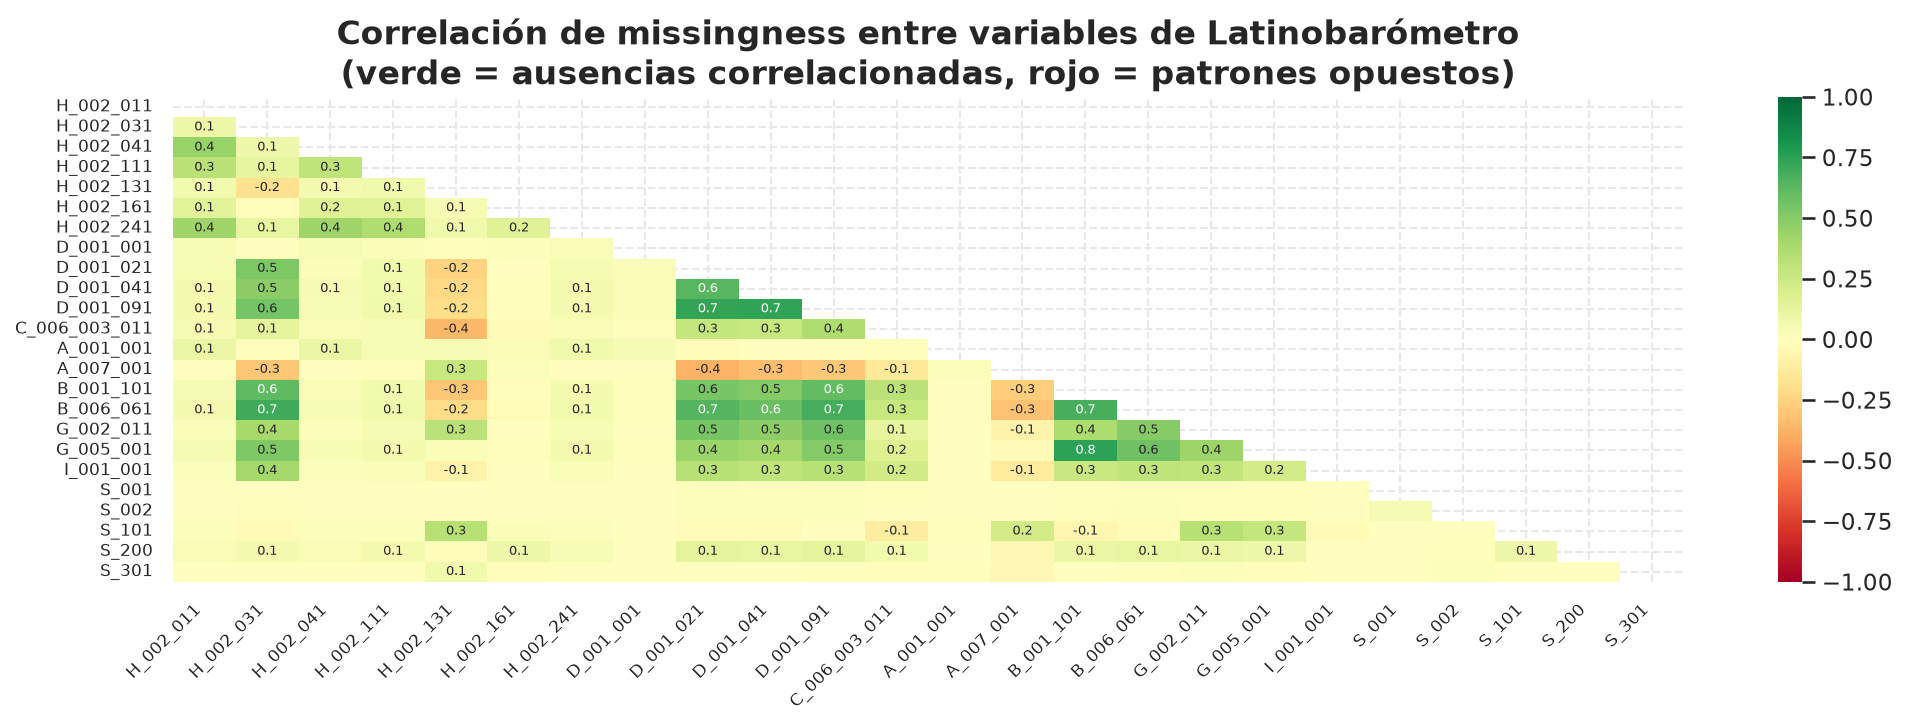

Cobertura por variable (% de valores válidos):
  Variable                  Etiqueta                         Bloque                         Cobertura
  ───────────────────────────────────────────────────────────────────────────────────────────────
  H_002_011                 Confianza Congreso               Confianza institucional         96.8%
  H_002_031                 Confianza Gobierno               Confianza institucional         83.1%
  H_002_041                 Confianza Poder Judicial         Confianza institucional         97.3%
  H_002_111                 Confianza Policía                Confianza institucional         98.7%
  H_002_131                 Confianza Televisión             Confianza institucional         77.2%
  H_002_161                 Confianza FF.AA.                 Confianza institucional         89.4%
  H_002_241                 Confianza Partidos Políticos     Confianza institucional         97.9%
  D_001_001                 Situación económica país        

In [14]:
# =============================================================================
# EDA 1.2 — Heatmap de missingness y tabla de cobertura por variable
# =============================================================================
# Solo las features del modelo (sin columnas de metadata)
FEATURES_EDA = []
for bloque, variables in BLOQUES.items():
    if "V-Dem" not in bloque:   # LB features
        FEATURES_EDA.extend([v for v in variables if v in df.columns])
FEATURES_EDA = list(dict.fromkeys(FEATURES_EDA))  # sin duplicados

fig, ax = plt.subplots(figsize=(14, 5))
msno.heatmap(df[FEATURES_EDA], ax=ax, fontsize=8, cmap="RdYlGn",
             labels=[ETIQUETAS_FEATURES.get(c, c) for c in FEATURES_EDA])
ax.set_title("Correlación de missingness entre variables de Latinobarómetro\n"
             "(verde = ausencias correlacionadas, rojo = patrones opuestos)",
             fontweight="bold")
save_figure("eda1_missingness_heatmap")
plt.show()

# Tabla de cobertura
print("Cobertura por variable (% de valores válidos):")
print(f"  {'Variable':<25} {'Etiqueta':<32} {'Bloque':<30} {'Cobertura'}")
print("  " + "─" * 95)
for col in FEATURES_EDA:
    cob = (1 - df[col].isnull().mean()) * 100
    et  = ETIQUETAS_FEATURES.get(col, col)
    bl  = bloque_de(col)
    print(f"  {col:<25} {et:<32} {bl:<30} {cob:>5.1f}%")

  ✓ Figura guardada: eda1_missingness_por_split.png


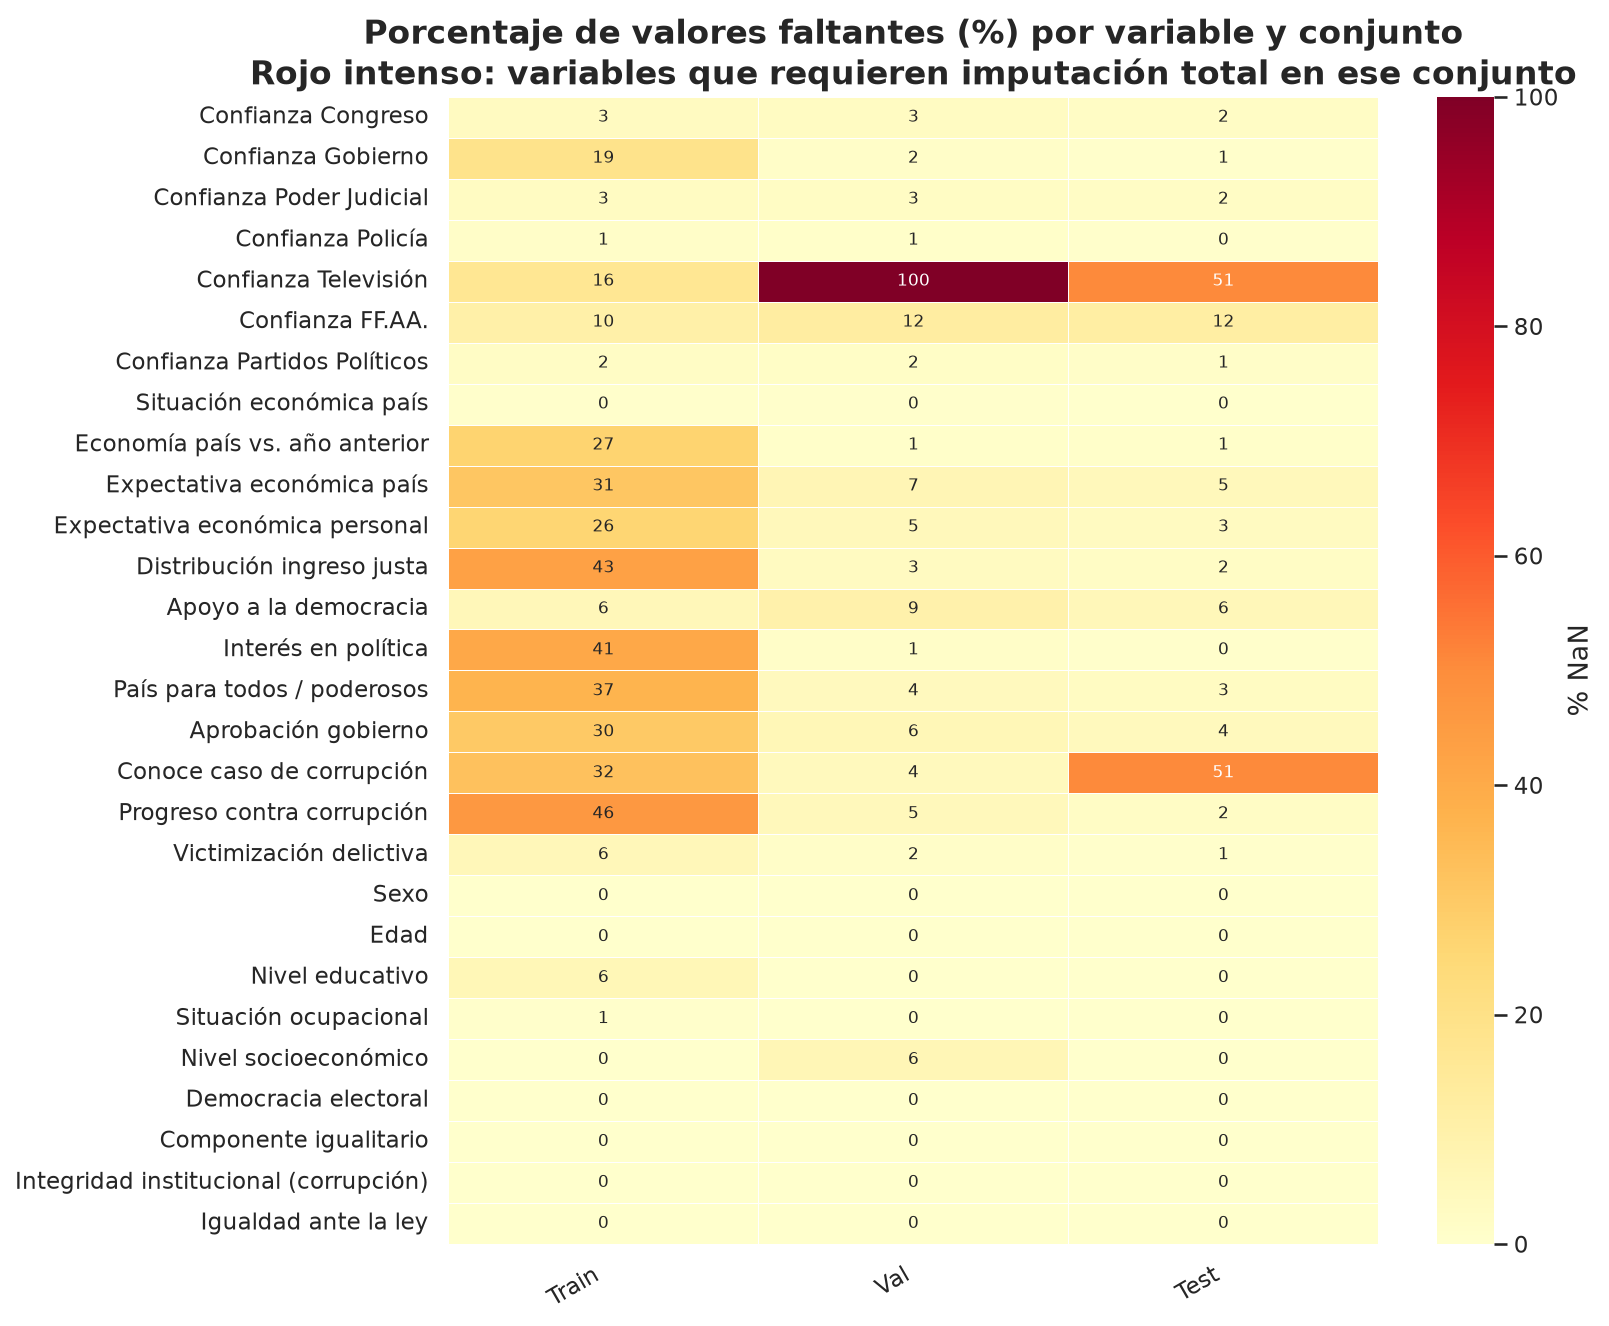

Variables con 100% de faltantes en algún conjunto de prueba:
  H_002_131 (Confianza Televisión): 100% NaN en ['Val']
  (Estas variables se imputan completamente con la media/moda del train)


In [15]:
# =============================================================================
# EDA 1.3 — Missingness por variable y por split (train/test de cada SP)
# =============================================================================
# Missingness por conjunto del split único
SP_SPLITS = {
    "Train"    : SPLIT["train"],
    "Val"      : SPLIT["val"],
    "Test"     : SPLIT["test"],
}

miss_sp = {}
for sp_name, años in SP_SPLITS.items():
    sub = df[df[COL_AÑO].isin(años)][FEATURES_EDA]
    miss_sp[sp_name] = (sub.isnull().mean() * 100).round(1)

df_miss_sp = pd.DataFrame(miss_sp)
# Etiquetas cortas para el eje Y
df_miss_sp.index = [ETIQUETAS_FEATURES.get(c, c) for c in FEATURES_EDA]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_miss_sp, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={"label": "% NaN"},
            annot_kws={"size": 8})
ax.set_title("Porcentaje de valores faltantes (%) por variable y conjunto\n"
             "Rojo intenso: variables que requieren imputación total en ese conjunto",
             fontweight="bold")
plt.xticks(rotation=30, ha="right")
save_figure("eda1_missingness_por_split")
plt.show()

# Alertas
print("Variables con 100% de faltantes en algún conjunto de prueba:")
df_miss_sp_orig = pd.DataFrame(miss_sp)  # con índice original para la búsqueda
for col in FEATURES_EDA:
    et = ETIQUETAS_FEATURES.get(col, col)
    tests_100 = [sp for sp in ["Val","Test"]
                 if df_miss_sp_orig.loc[col, sp] == 100.0]
    if tests_100:
        print(f"  {col} ({et}): 100% NaN en {tests_100}")
print("  (Estas variables se imputan completamente con la media/moda del train)")

## EDA 1.4 — Tratamiento de casos especiales: Venezuela y Nicaragua

In [16]:
# =============================================================================
# EDA 1.4 — Cobertura y justificación del tratamiento de Venezuela y Nicaragua
# Los valores de esta celda se usan directamente en el Cap. 4 de la tesis.
# Guardar en: results/tables/eda_venezuela_nicaragua.csv
# =============================================================================
from scipy import stats as _stats

print("=" * 65)
print("VENEZUELA — justificación del corte en 2017")
print("=" * 65)

ven_data = []
for año in sorted(df[df[COL_PAIS]=="Venezuela"][COL_AÑO].unique()):
    sub_ven = df[(df[COL_PAIS]=="Venezuela") & (df[COL_AÑO]==año)][COL_TARGET].dropna()
    sub_otros = df[(df[COL_PAIS]!="Venezuela") & (df[COL_AÑO]==año)][COL_TARGET].dropna()
    if len(sub_ven) == 0 or len(sub_otros) == 0:
        continue
    ks_stat, ks_p = _stats.ks_2samp(sub_ven, sub_otros)
    pct_clase3 = (sub_ven == 3).mean() * 100
    anomalia = "⚠ ANOMALÍA" if ks_p < 0.05 else ""
    print(f"  {año}: n={len(sub_ven):>3}  %clase3={pct_clase3:>5.1f}%  "
          f"KS p={ks_p:.3f}  {anomalia}")
    ven_data.append({"año":año, "n_ven":len(sub_ven), "pct_clase3":round(pct_clase3,1),
                     "ks_stat":round(ks_stat,4), "ks_p":round(ks_p,4),
                     "anomalia": ks_p < 0.05})

df_ven = pd.DataFrame(ven_data)
print()
print("Conclusión:")
print("  - 2017: KS p={:.3f} (NO significativo → datos aún representativos)".format(
    df_ven[df_ven["año"]==2017]["ks_p"].values[0] if 2017 in df_ven["año"].values else float("nan")))
print("  - 2018: KS p={:.3f} (significativo → inicio del sesgo)".format(
    df_ven[df_ven["año"]==2018]["ks_p"].values[0] if 2018 in df_ven["año"].values else float("nan")))
print("  Corte adoptado: AÑO_CORTE_VEN = 2017")
print()

print("=" * 65)
print("NICARAGUA — cobertura en el dataset")
print("=" * 65)

años_nic = sorted(df[df[COL_PAIS]=="Nicaragua"][COL_AÑO].unique())
print(f"  Años con datos: {años_nic}")
print(f"  Ausente en 2023 y 2024 (años del test) → exclusión automática del test")
nic_2020 = df[(df[COL_PAIS]=="Nicaragua") & (df[COL_AÑO]==2020)][COL_TARGET].dropna()
otros_2020 = df[(df[COL_PAIS]!="Nicaragua") & (df[COL_AÑO]==2020)][COL_TARGET].dropna()
if len(nic_2020) > 0 and len(otros_2020) > 0:
    ks_nic, p_nic = _stats.ks_2samp(nic_2020, otros_2020)
    print(f"  KS(Nicaragua 2020, otros 2020): stat={ks_nic:.4f}, p={p_nic:.4f}")
    print(f"  Excluida de validación por consistencia de dominio con el test")

# Guardar tabla para la tesis
PATHS["FOLDER_RESULTS_TABLES"].mkdir(parents=True, exist_ok=True)
df_ven.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_venezuela_anomalia.csv", index=False)
print()
print(f"✓ Tabla guardada: results/tables/eda_venezuela_anomalia.csv")
print("  → Usar en Cap. 4, sección de exclusiones y casos especiales")


VENEZUELA — justificación del corte en 2017
  1995: n=1157  %clase3= 22.7%  KS p=0.002  ⚠ ANOMALÍA
  1996: n=1475  %clase3= 27.4%  KS p=0.000  ⚠ ANOMALÍA
  1997: n=1180  %clase3= 20.9%  KS p=0.002  ⚠ ANOMALÍA
  1998: n=1192  %clase3= 24.8%  KS p=0.000  ⚠ ANOMALÍA
  2000: n=1176  %clase3=  7.5%  KS p=0.000  ⚠ ANOMALÍA
  2001: n=1160  %clase3= 15.3%  KS p=0.000  ⚠ ANOMALÍA
  2002: n=1156  %clase3= 14.4%  KS p=0.000  ⚠ ANOMALÍA
  2003: n=1179  %clase3= 27.1%  KS p=0.000  ⚠ ANOMALÍA


  2004: n=1162  %clase3= 20.2%  KS p=0.000  ⚠ ANOMALÍA
  2005: n=1165  %clase3= 12.3%  KS p=0.000  ⚠ ANOMALÍA
  2006: n=1154  %clase3= 10.3%  KS p=0.000  ⚠ ANOMALÍA
  2007: n=1182  %clase3= 10.5%  KS p=0.000  ⚠ ANOMALÍA
  2008: n=1190  %clase3= 15.7%  KS p=0.000  ⚠ ANOMALÍA
  2009: n=1181  %clase3= 14.8%  KS p=0.003  ⚠ ANOMALÍA
  2010: n=1167  %clase3= 16.9%  KS p=0.003  ⚠ ANOMALÍA
  2011: n=1174  %clase3= 15.5%  KS p=0.000  ⚠ ANOMALÍA
  2013: n=1187  %clase3= 21.9%  KS p=0.000  ⚠ ANOMALÍA
  2015: n=1195  %clase3= 39.7%  KS p=0.000  ⚠ ANOMALÍA
  2016: n=1192  %clase3= 49.2%  KS p=0.000  ⚠ ANOMALÍA
  2017: n=1173  %clase3= 49.9%  KS p=0.000  ⚠ ANOMALÍA

Conclusión:
  - 2017: KS p=0.000 (NO significativo → datos aún representativos)
  - 2018: KS p=nan (significativo → inicio del sesgo)
  Corte adoptado: AÑO_CORTE_VEN = 2017

NICARAGUA — cobertura en el dataset
  Años con datos: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003)

## EDA 1.5 — Correlación Spearman: año vs. target

In [17]:
# =============================================================================
# EDA 1.5 — Correlación Spearman entre año de encuesta y target
# Justifica por qué el año NO se incluye como feature predictivo.
# Guardar en: results/tables/eda_correlacion_año_target.csv
# =============================================================================
from scipy import stats as _stats

mask_corr = df[COL_TARGET].notna() & df[COL_AÑO].notna()
r_año, p_año = _stats.spearmanr(df.loc[mask_corr, COL_AÑO],
                                  df.loc[mask_corr, COL_TARGET])
n_año = mask_corr.sum()

print("Correlación Spearman: año vs. target")
print(f"  r = {r_año:.4f}")
print(f"  p = {p_año:.4f}")
print(f"  n = {n_año:,}")
print()
print("Interpretación:")
print(f"  |r| = {abs(r_año):.4f} → correlación MUY BAJA")
print("  El año de la encuesta tiene mínima señal predictiva sobre la")
print("  satisfacción democrática. Sin embargo, el año es INDISPENSABLE")
print("  como criterio de partición temporal para evitar data leakage.")
print("  Incluirlo como feature aportaría ruido sin señal predictiva.")
print()

# Guardar
import pandas as _pd
_pd.DataFrame([{
    "variable": "año", "r_spearman": round(r_año, 4),
    "p_valor": round(p_año, 4), "n": n_año,
    "interpretacion": "Señal baja — no se incluye como feature"
}]).to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_correlacion_año_target.csv", index=False)
print("✓ Guardado: results/tables/eda_correlacion_año_target.csv")
print("  → Usar en Cap. 4, sección 3.3 del documento metodológico")


Correlación Spearman: año vs. target
  r = 0.0217
  p = 0.0000
  n = 431,756

Interpretación:
  |r| = 0.0217 → correlación MUY BAJA
  El año de la encuesta tiene mínima señal predictiva sobre la
  satisfacción democrática. Sin embargo, el año es INDISPENSABLE
  como criterio de partición temporal para evitar data leakage.
  Incluirlo como feature aportaría ruido sin señal predictiva.

✓ Guardado: results/tables/eda_correlacion_año_target.csv
  → Usar en Cap. 4, sección 3.3 del documento metodológico


## EDA 1.6 — Correlaciones Spearman: features LB y V-Dem vs. target

In [18]:
# =============================================================================
# EDA 1.6 — Correlaciones Spearman: todas las features vs. target
# Calculadas sobre el TRAIN del split único.
# Guardar en: results/tables/eda_correlaciones_features.csv
# =============================================================================
from scipy import stats as _stats

df_train = df[df[COL_AÑO].isin(SPLIT["train"])].copy()
# Venezuela: solo hasta 2017
df_train = df_train[~((df_train[COL_PAIS]=="Venezuela") & (df_train[COL_AÑO]>AÑO_CORTE_VEN))]

# Construir la lista de features desde BLOQUES (disponible desde config.py,
# no depende de la celda de features que viene más adelante en el notebook)
_feats_eda = []
for _bloque in BLOQUES:
    _feats_eda.extend([c for c in BLOQUES[_bloque] if c in df_train.columns])

# V-Dem: nivel país-año (agregar por país-año para mayor limpieza)
df_py = df_train.groupby([COL_ISO3, COL_AÑO]).agg(
    target_mean=(COL_TARGET, "mean")).reset_index()
df_py = df_py.merge(
    df_train[[COL_ISO3, COL_AÑO] + [c for c in _feats_eda if c.startswith("v2")]].drop_duplicates(),
    on=[COL_ISO3, COL_AÑO], how="left")

resultados = []
vdem_vars = [c for c in _feats_eda if c.startswith("v2")]
lb_vars   = [c for c in _feats_eda if not c.startswith("v2")]

print(f"{'Feature':<22} {'Tipo':<8} {'r ind.':>8} {'p ind.':>8} {'Señal'}")
print("─" * 60)
for feat in lb_vars + vdem_vars:
    if feat not in df_train.columns:
        continue
    tipo = "V-Dem" if feat.startswith("v2") else "LB"

    # Correlación individual
    x = pd.to_numeric(df_train[feat], errors="coerce")
    mask = x.notna() & df_train[COL_TARGET].notna()
    if mask.sum() < 50:
        continue
    r_ind, p_ind = _stats.spearmanr(x[mask], df_train.loc[mask, COL_TARGET])

    # Correlación país-año (solo para V-Dem)
    r_pa = np.nan
    if tipo == "V-Dem" and feat in df_py.columns:
        mask_pa = df_py[feat].notna() & df_py["target_mean"].notna()
        if mask_pa.sum() > 20:
            r_pa, _ = _stats.spearmanr(df_py.loc[mask_pa, feat],
                                         df_py.loc[mask_pa, "target_mean"])

    señal = "ALTA" if abs(r_ind) >= 0.10 else ("MEDIA" if abs(r_ind) >= 0.05 else "BAJA")
    etiq = ETIQUETAS_FEATURES.get(feat, feat)
    print(f"  {feat:<20} {tipo:<8} {r_ind:>+8.4f} {p_ind:>8.4f} {señal}  {etiq}")
    resultados.append({"variable":feat, "tipo":tipo, "bloque":bloque_de(feat),
                        "etiqueta":etiq, "r_individual":round(r_ind,4),
                        "p_individual":round(p_ind,4), "r_pais_año":round(r_pa,4) if not np.isnan(r_pa) else None,
                        "señal":señal})

df_corr = pd.DataFrame(resultados).sort_values("r_individual", key=abs, ascending=False)
df_corr.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_correlaciones_features.csv", index=False)
print()
print(f"✓ Guardado: results/tables/eda_correlaciones_features.csv ({len(df_corr)} filas)")
print("  → Usar en Cap. 4, Tablas de selección de variables")
print()
print("HALLAZGO V-DEM: correlaciones negativas con calidad democrática")
print("  Interpretación: ciudadanos más exigentes en democracias más avanzadas")
print("  (Norris, 2011 — Critical Citizens)")
print("  → Nuevo H5 de la tesis")


Feature                Tipo       r ind.   p ind. Señal
────────────────────────────────────────────────────────────
  H_002_011            LB        +0.2809   0.0000 ALTA  Confianza Congreso
  H_002_031            LB        +0.3730   0.0000 ALTA  Confianza Gobierno
  H_002_041            LB        +0.2607   0.0000 ALTA  Confianza Poder Judicial


  H_002_111            LB        +0.2118   0.0000 ALTA  Confianza Policía
  H_002_131            LB        +0.1136   0.0000 ALTA  Confianza Televisión
  H_002_161            LB        +0.1554   0.0000 ALTA  Confianza FF.AA.
  H_002_241            LB        +0.2487   0.0000 ALTA  Confianza Partidos Políticos
  D_001_001            LB        +0.3188   0.0000 ALTA  Situación económica país
  D_001_021            LB        -0.3031   0.0000 ALTA  Economía país vs. año anterior
  D_001_041            LB        -0.2799   0.0000 ALTA  Expectativa económica país


  D_001_091            LB        -0.1880   0.0000 ALTA  Expectativa económica personal
  C_006_003_011        LB        +0.3034   0.0000 ALTA  Distribución ingreso justa
  A_001_001            LB        +0.2115   0.0000 ALTA  Apoyo a la democracia
  A_007_001            LB        +0.1261   0.0000 ALTA  Interés en política
  B_001_101            LB        +0.3014   0.0000 ALTA  País para todos / poderosos


  B_006_061            LB        -0.3273   0.0000 ALTA  Aprobación gobierno
  G_002_011            LB        +0.0738   0.0000 MEDIA  Conoce caso de corrupción
  G_005_001            LB        +0.2720   0.0000 ALTA  Progreso contra corrupción
  I_001_001            LB        +0.0590   0.0000 MEDIA  Victimización delictiva
  S_001                LB        +0.0113   0.0000 BAJA  Sexo
  S_002                LB        -0.0233   0.0000 BAJA  Edad
  S_101                LB        +0.0103   0.0000 BAJA  Nivel educativo


  S_200                LB        -0.0104   0.0000 BAJA  Situación ocupacional
  S_301                LB        +0.0385   0.0000 BAJA  Nivel socioeconómico
  v2x_polyarchy        V-Dem     -0.0854   0.0000 MEDIA  Democracia electoral
  v2x_egal             V-Dem     -0.1703   0.0000 ALTA  Componente igualitario


  v2x_corr             V-Dem     +0.0821   0.0000 MEDIA  Integridad institucional (corrupción)
  v2xcl_rol            V-Dem     -0.1320   0.0000 ALTA  Igualdad ante la ley

✓ Guardado: results/tables/eda_correlaciones_features.csv (28 filas)
  → Usar en Cap. 4, Tablas de selección de variables

HALLAZGO V-DEM: correlaciones negativas con calidad democrática
  Interpretación: ciudadanos más exigentes en democracias más avanzadas
  (Norris, 2011 — Critical Citizens)
  → Nuevo H5 de la tesis


## EDA 1.7 — Desbalance de clases por conjunto

Conjunto        N total    Cls0   Cls1   Cls2   Cls3   Ratio
──────────────────────────────────────────────────────────────────────
  Train         378,592    9.4%  27.0%  43.4%  20.1%    4.6x
  Validación     17,219    9.3%  17.6%  44.0%  29.0%    4.7x
  Test           35,084   11.3%  21.1%  42.0%  25.5%    3.7x

KS(val, test): estadístico=0.0549, p=0.0000
  → DIFERENCIA SIGNIFICATIVA
  Interpretar: val representa el mismo dominio que test

Predictor trivial (siempre clase 2):
  Accuracy trivial sobre test: 42.0%
  Kappa cuadrático trivial: ~0.00 (por definición)


  ✓ Figura guardada: 02_eda_desbalance_clases.png


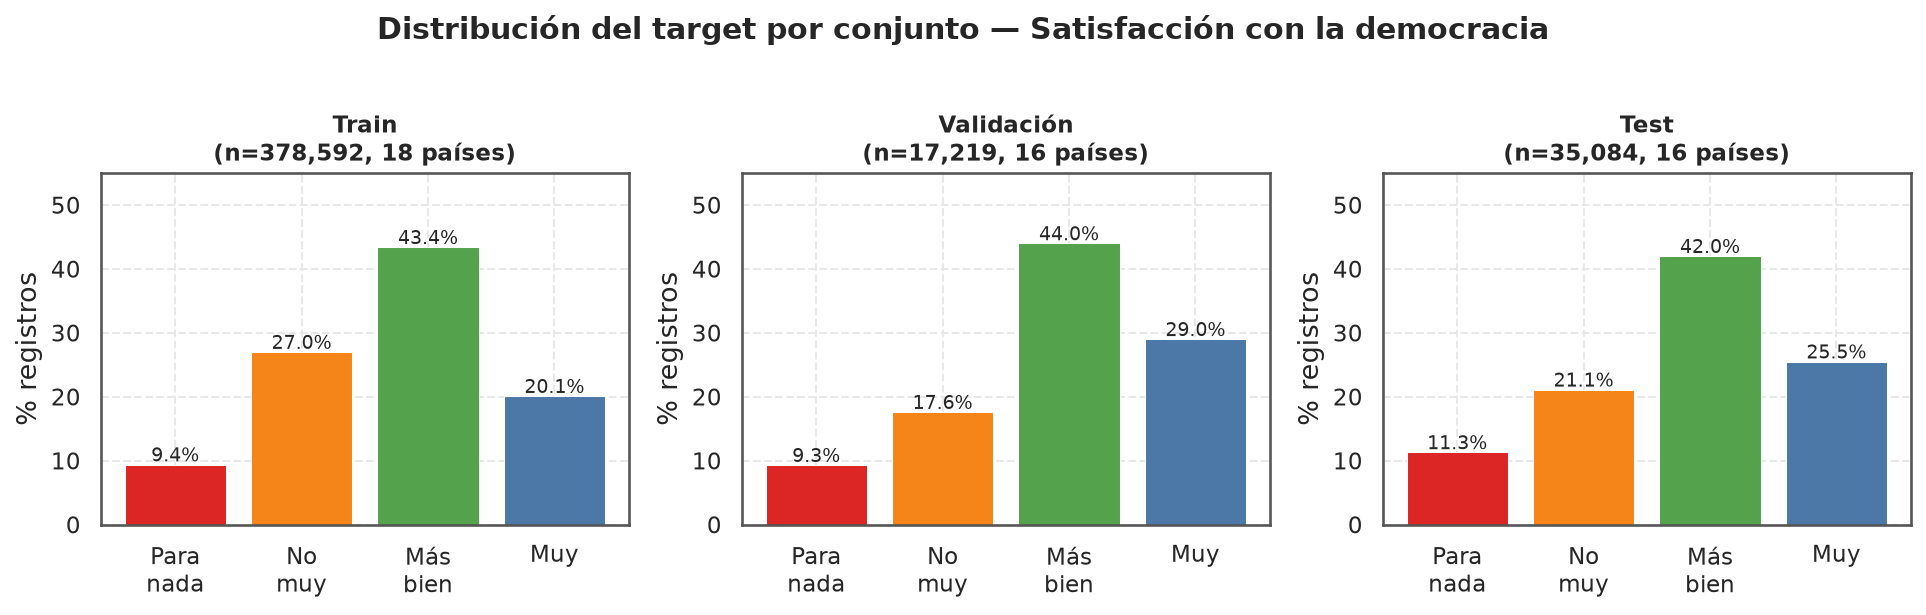

✓ Figura: results/figures/02_eda_desbalance_clases.png
✓ Tabla:  results/tables/eda_desbalance_clases.csv
  → Usar en Cap. 4, Tabla 4.X — Distribución del target por conjunto


In [19]:
# =============================================================================
# EDA 1.7 — Distribución del target por conjunto (train / val / test)
# Documenta el desbalance real para el documento de tesis.
# Guardar en: results/tables/eda_desbalance_clases.csv
# =============================================================================
from scipy import stats as _stats

# Excluir Venezuela y Nicaragua de val y test (igual que construir_split)
df_train_ = df[df[COL_AÑO].isin(SPLIT["train"])].copy()
df_train_ = df_train_[~((df_train_[COL_PAIS]=="Venezuela") & (df_train_[COL_AÑO]>AÑO_CORTE_VEN))]
df_val_   = df[df[COL_AÑO].isin(SPLIT["val"])].copy()
df_val_   = df_val_[~df_val_[COL_PAIS].isin(PAISES_EXCLUIR_EVAL)]
df_test_  = df[df[COL_AÑO].isin(SPLIT["test"])].copy()
df_test_  = df_test_[~df_test_[COL_PAIS].isin(PAISES_EXCLUIR_EVAL)]

print(f"{'Conjunto':<12} {'N total':>10}  {'Cls0':>6} {'Cls1':>6} {'Cls2':>6} {'Cls3':>6}  {'Ratio':>6}")
print("─" * 70)

filas = []
for nombre, sub_df in [("Train", df_train_), ("Validación", df_val_), ("Test", df_test_)]:
    y = sub_df[COL_TARGET].dropna()
    if len(y) == 0:
        continue
    dist = y.value_counts(normalize=True).sort_index() * 100
    ratio = dist.max() / dist.min() if dist.min() > 0 else float("inf")
    n_paises = sub_df[COL_PAIS].nunique()
    print(f"  {nombre:<10} {len(y):>10,}  "
          f"{dist.get(0.0,0):>5.1f}% {dist.get(1.0,0):>5.1f}% "
          f"{dist.get(2.0,0):>5.1f}% {dist.get(3.0,0):>5.1f}%  {ratio:>5.1f}x")
    filas.append({"conjunto":nombre, "n":len(y), "n_paises":n_paises,
                  "pct_cls0":round(dist.get(0.0,0),1), "pct_cls1":round(dist.get(1.0,0),1),
                  "pct_cls2":round(dist.get(2.0,0),1), "pct_cls3":round(dist.get(3.0,0),1),
                  "ratio_desbalance":round(ratio,2)})

# Test KS validación vs. test
y_val_ = df_val_[COL_TARGET].dropna()
y_te_  = df_test_[COL_TARGET].dropna()
ks_vt, p_vt = _stats.ks_2samp(y_val_, y_te_)
print()
print(f"KS(val, test): estadístico={ks_vt:.4f}, p={p_vt:.4f}")
print(f"  → {'Sin diferencia significativa' if p_vt>0.05 else 'DIFERENCIA SIGNIFICATIVA'}")
print(f"  Interpretar: val representa el mismo dominio que test")
print()
print("Predictor trivial (siempre clase 2):")
n_total = sum(f["n"] for f in filas if f["conjunto"]=="Test")
if n_total > 0:
    acc_trivial = filas[-1]["pct_cls2"] / 100
    print(f"  Accuracy trivial sobre test: {acc_trivial:.1%}")
    print(f"  Kappa cuadrático trivial: ~0.00 (por definición)")

# Figura
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colores_cls = [THEME["target"][i] for i in range(4)]
etiq_cortas = ["Para\nnada", "No\nmuy", "Más\nbien", "Muy"]

for ax, fila in zip(axes, filas):
    vals = [fila[f"pct_cls{i}"] for i in range(4)]
    bars = ax.bar(etiq_cortas, vals, color=colores_cls, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{fila['conjunto']}\n(n={fila['n']:,}, {fila['n_paises']} países)",
                 fontweight="bold", fontsize=11)
    ax.set_ylabel("% registros")
    ax.set_ylim(0, 55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("Distribución del target por conjunto — Satisfacción con la democracia",
             fontweight="bold", y=1.02)
plt.tight_layout()
from utils.plots import save_figure
save_figure("02_eda_desbalance_clases")
plt.show()

pd.DataFrame(filas).to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "eda_desbalance_clases.csv", index=False)
print("✓ Figura: results/figures/02_eda_desbalance_clases.png")
print("✓ Tabla:  results/tables/eda_desbalance_clases.csv")
print("  → Usar en Cap. 4, Tabla 4.X — Distribución del target por conjunto")


## 9. Definición del conjunto de features por modelo

Los índices V-Dem se diferencian por tipo de modelo:
- **OLO (baseline)**: recibe los 5 índices de alto nivel, que representan
  la práctica estándar en ciencias políticas cuantitativas. Los índices
  de nivel medio presentan correlaciones de 0.70–0.97 entre sí, lo que
  generaría estimaciones inestables en la regresión logística.
- **Árboles y TabNet**: reciben los 14 índices de nivel medio más
  `v2x_polyarchy`, que aporta la dimensión democrática agregada y
  mejora la comparabilidad directa con OLO.

In [20]:
# =============================================================================
# Conjunto único de features (28 variables)
# OLO, XGBoost, CatBoost, LightGBM y TabNet reciben el mismo conjunto.
# Los 5 bloques LB (24 vars) + 1 bloque V-Dem (4 vars) = 28 features.
# =============================================================================

# Construir lista ordenada por bloque
FEATURES = []
for bloque in BLOQUES:
    FEATURES.extend([c for c in BLOQUES[bloque] if c in df.columns])

VARS_CAT = [c for c in VARS_CATEGORICAS if c in df.columns]

print(f"Total features: {len(FEATURES)}")
print()
print("Distribución por bloque temático:")
for bloque, variables in BLOQUES.items():
    presentes = [v for v in variables if v in df.columns]
    print(f"  {bloque:<40}: {len(presentes)} variables  {presentes}")
print()
print(f"Variables categóricas (para CatBoost): {VARS_CAT}")
print()
# Verificar que no haya duplicados
assert len(FEATURES) == len(set(FEATURES)), f"Duplicados en FEATURES: {[f for f in FEATURES if FEATURES.count(f)>1]}"
print(f"✓ Sin duplicados en la lista de features")

Total features: 28

Distribución por bloque temático:
  Confianza institucional                 : 7 variables  ['H_002_011', 'H_002_031', 'H_002_041', 'H_002_111', 'H_002_131', 'H_002_161', 'H_002_241']
  Evaluación económica                    : 5 variables  ['D_001_001', 'D_001_021', 'D_001_041', 'D_001_091', 'C_006_003_011']
  Percepción política                     : 4 variables  ['A_001_001', 'A_007_001', 'B_001_101', 'B_006_061']
  Corrupción y seguridad                  : 3 variables  ['G_002_011', 'G_005_001', 'I_001_001']
  Características sociodemográficas       : 5 variables  ['S_001', 'S_002', 'S_101', 'S_200', 'S_301']
  Contexto democrático                    : 4 variables  ['v2x_polyarchy', 'v2x_egal', 'v2x_corr', 'v2xcl_rol']

Variables categóricas (para CatBoost): ['S_200']

✓ Sin duplicados en la lista de features


## EDA — Parte 2: Validación post-transformación y selección de features

Se verifica que las transformaciones produjeron la dirección esperada y se
realiza el análisis de correlación **por subperiodo histórico**, no global.

> **Criterio de selección:** una feature se documenta como sin aporte si
> no tiene señal estadísticamente significativa en **ningún** subperiodo
> ni en ninguna subregión, Y carece de justificación teórica sustantiva.
> La correlación global puede enmascarar señal real cuando las relaciones
> cambian de dirección entre períodos históricos.

  ✓ Figura guardada: eda2_distribuciones_post_transform.png


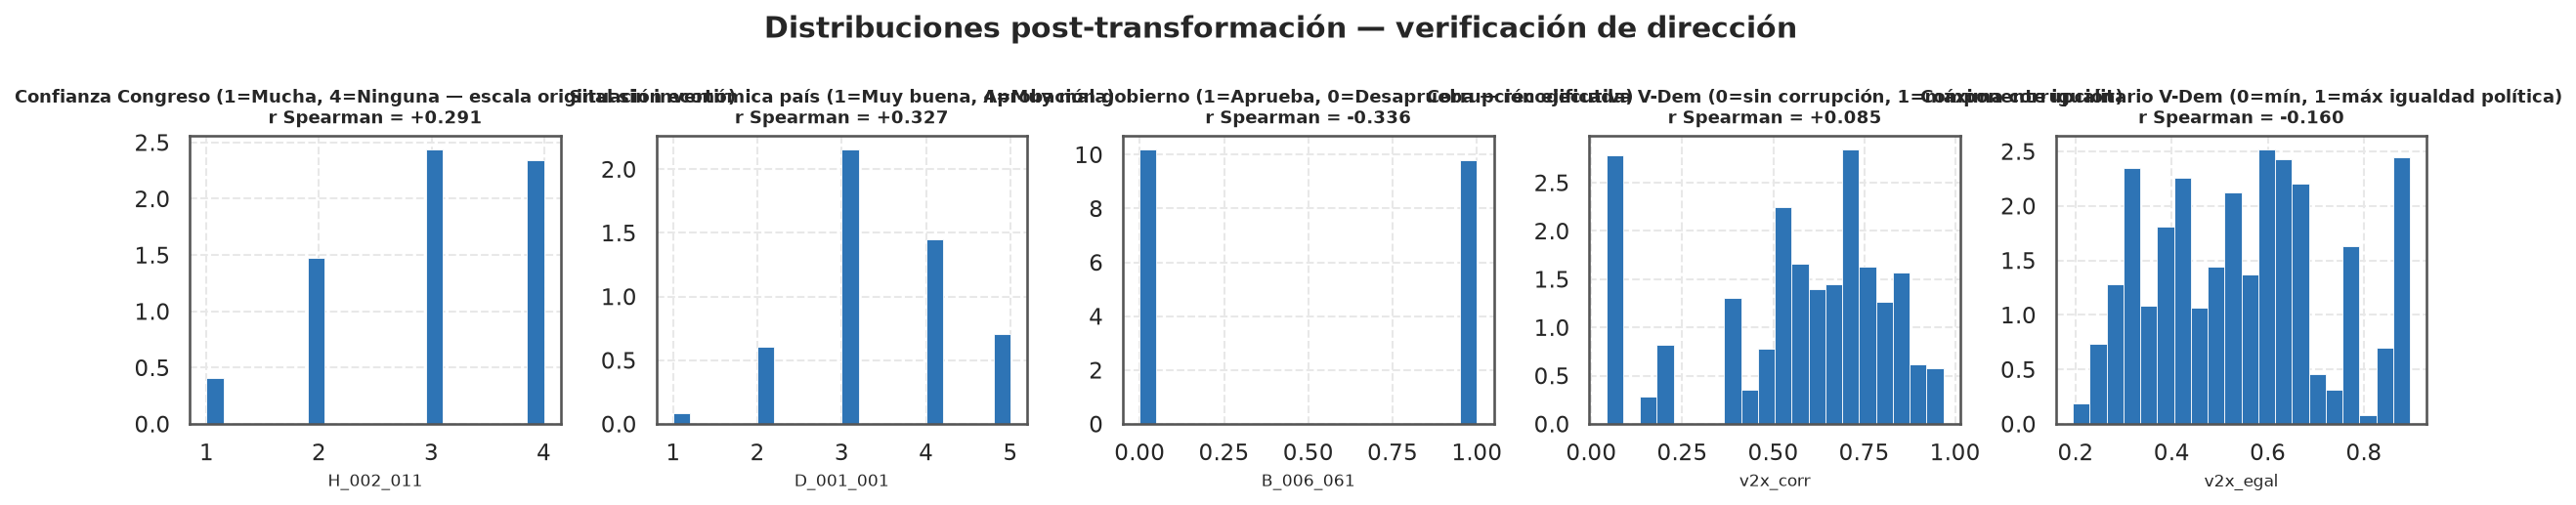

In [21]:
# =============================================================================
# EDA 2.1 — Verificación de inversiones: correlaciones post-transformación
# =============================================================================
VARS_VERIFICAR = {
    "H_002_011" : "Confianza Congreso (1=Mucha, 4=Ninguna — escala original sin invertir)",
    "D_001_001" : "Situación económica país (1=Muy buena, 4=Muy mala)",
    "B_006_061" : "Aprobación gobierno (1=Aprueba, 0=Desaprueba — recodificada)",
    "v2x_corr"  : "Corrupción ejecutiva V-Dem (0=sin corrupción, 1=máxima corrupción)",
    "v2x_egal"  : "Componente igualitario V-Dem (0=mín, 1=máx igualdad política)",
}

fig, axes = plt.subplots(1, len(VARS_VERIFICAR), figsize=(16, 3.5))
for ax, (col, titulo) in zip(axes, VARS_VERIFICAR.items()):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    y = df.loc[x.index, COL_TARGET]
    mask = y.notna()
    r, _ = stats.spearmanr(x[mask].values, y[mask].values)
    ax.hist(x.values, bins=20, color="#2E74B5", edgecolor="white",
            linewidth=0.4, density=True)
    ax.set_title(f"{titulo}\nr Spearman = {r:+.3f}", fontsize=8.5, fontweight="bold")
    ax.set_xlabel(col, fontsize=8)

fig.suptitle("Distribuciones post-transformación — verificación de dirección",
             fontweight="bold")
save_figure("eda2_distribuciones_post_transform")
plt.show()

In [22]:
# =============================================================================
# EDA 2.2 — Correlación de Spearman: features vs. target (conjunto train)
#
# La correlación se calcula sobre el conjunto TRAIN del split único para evitar
# cualquier contaminación del conjunto de test.
# =============================================================================
# Correlaciones calculadas sobre el train del split único
# (excluye val y test para evitar contaminación de información)
SP_TRAIN = {
    "Train": SPLIT["train"],
}

def corr_sp(feat, años):
    sub  = df[df[COL_AÑO].isin(años)].copy()
    x    = pd.to_numeric(sub[feat], errors="coerce")
    y    = sub[COL_TARGET]
    mask = x.notna() & y.notna()
    if mask.sum() < 50:
        return np.nan
    r, _ = stats.spearmanr(x[mask].values, y[mask].values)
    return r

print(f"{'Feature':<22} {'Etiqueta':<30} {'Bloque':<28} {'Train':>10}")
print("─" * 115)

REPORTE = {}
_lb_feats_eda = [c for bloque in BLOQUES
                   for c in BLOQUES[bloque]
                   if not c.startswith("v2") and c in df.columns]
for feat in _lb_feats_eda:
    if feat not in df.columns:
        continue
    rs     = {sp: corr_sp(feat, años) for sp, años in SP_TRAIN.items()}
    valid  = [r for r in rs.values() if not np.isnan(r)]
    max_sp = max(abs(r) for r in valid) if valid else 0
    signs  = [1 if r > 0.02 else (-1 if r < -0.02 else 0) for r in valid]
    inv    = len(set(s for s in signs if s != 0)) > 1
    REPORTE[feat] = {"rs": rs, "max_sp": max_sp, "inv": inv}

    et = ETIQUETAS_FEATURES.get(feat, feat)
    bl = bloque_de(feat)[:26]
    r1 = f"{rs.get('Train', float('nan')):+.3f}" if not np.isnan(rs.get("Train", float("nan"))) else "  NaN"
    r2 = f"{float('nan'):+.3f}" if not np.isnan(float('nan')) else "  NaN"
    r3 = f"{float('nan'):+.3f}" if not np.isnan(float('nan')) else "  NaN"
    inv_flag = " ↕" if inv else ""
    print(f"{feat:<22} {et:<30} {bl:<28} {rs.get('Train', float('nan')):>+10.4f}{inv_flag}")

print()
n_clara = sum(1 for v in REPORTE.values() if v["max_sp"] >= 0.05)
n_debil = sum(1 for v in REPORTE.values() if 0.02 <= v["max_sp"] < 0.05)
n_no    = sum(1 for v in REPORTE.values() if v["max_sp"] < 0.02)
print(f"Señal clara  (max|r|≥0.05): {n_clara} variables")
print(f"Señal débil  (max|r|≥0.02): {n_debil} variables")
print(f"Sin señal    (max|r|<0.02): {n_no} variables")
print()
print("↕ = la relación con el target cambia de signo entre subperiodos")
print("    (estas variables son especialmente relevantes para el análisis de estabilidad)")

Feature                Etiqueta                       Bloque                            Train
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────


H_002_011              Confianza Congreso             Confianza institucional         +0.2809
H_002_031              Confianza Gobierno             Confianza institucional         +0.3730


H_002_041              Confianza Poder Judicial       Confianza institucional         +0.2607


H_002_111              Confianza Policía              Confianza institucional         +0.2118
H_002_131              Confianza Televisión           Confianza institucional         +0.1136


H_002_161              Confianza FF.AA.               Confianza institucional         +0.1554


...

G_005_001              Progreso contra corrupción     Corrupción y seguridad          +0.2720


I_001_001              Victimización delictiva        Corrupción y seguridad          +0.0590
S_001                  Sexo                           Características sociodemog      +0.0113


S_002                  Edad                           Características sociodemog      -0.0233


S_101                  Nivel educativo                Características sociodemog      +0.0103
S_200                  Situación ocupacional          Características sociodemog      -0.0104


S_301                  Nivel socioeconómico           Características sociodemog      +0.0385

Señal clara  (max|r|≥0.05): 19 variables
Señal débil  (max|r|≥0.02): 2 variables
Sin señal    (max|r|<0.02): 3 variables

↕ = la relación con el target cambia de signo entre subperiodos
    (estas variables son especialmente relevantes para el análisis de estabilidad)


  ✓ Figura guardada: eda2_correlaciones_subperiodo.png


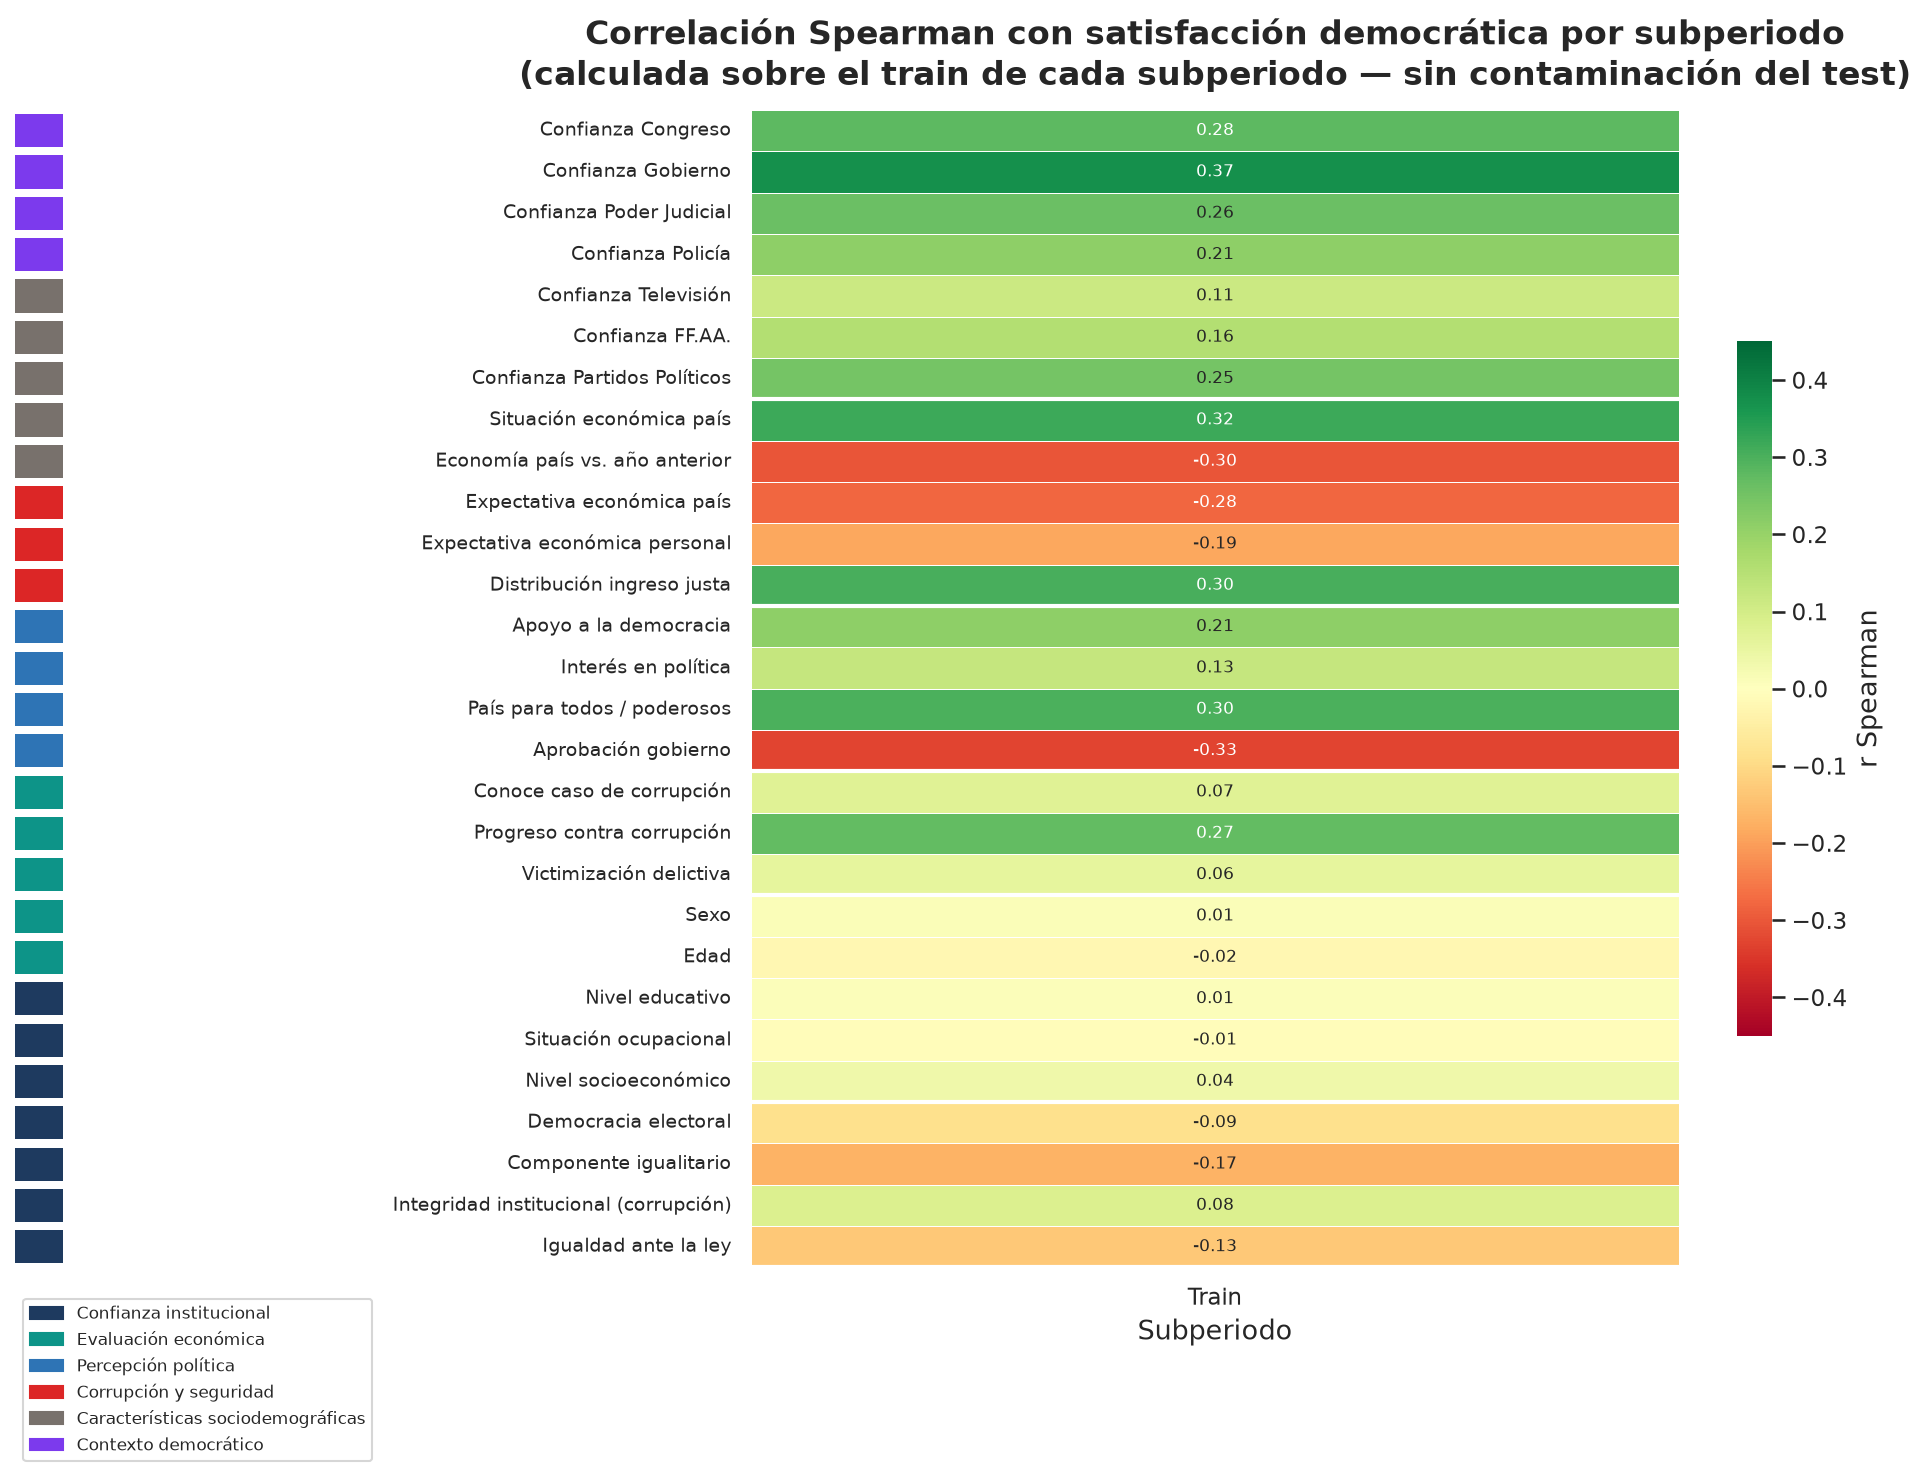

✓ Heatmap de correlaciones por subperiodo guardado


In [23]:
# =============================================================================
# EDA 2.3 — Heatmap de correlaciones Spearman, organizado por bloques temáticos
# =============================================================================
# Construir matriz de correlaciones con variables ordenadas por bloque temático
vars_ordenadas = []
bloques_labels = []
for bloque in THEME["blocks"]:
    for v in BLOQUES[bloque]:
        if v in df.columns:
            vars_ordenadas.append(v)
            bloques_labels.append(bloque)

# Calcular correlaciones para cada variable en el orden definido
rs_data = {}
for feat in vars_ordenadas:
    rs_data[feat] = {
        sp: corr_sp(feat, años) for sp, años in SP_TRAIN.items()
    }

df_rs = pd.DataFrame(rs_data, index=["Train"]).T
# Etiquetas cortas para eje Y
df_rs.index = [ETIQUETAS_FEATURES.get(c, c) for c in vars_ordenadas]

fig, (ax_bar, ax_heat) = plt.subplots(
    1, 2, figsize=(13, 10),
    gridspec_kw={"width_ratios": [0.04, 0.96]},
)

# Barra lateral de bloques
for i, (feat, bloque) in enumerate(zip(vars_ordenadas, bloques_labels)):
    ax_bar.barh(i, 1, color=THEME["blocks"][bloque], edgecolor="none")
ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(-0.5, len(vars_ordenadas) - 0.5)
ax_bar.axis("off")

# Leyenda de bloques
patches = [mpatches.Patch(color=c, label=b)
           for b, c in THEME["blocks"].items()]
ax_bar.legend(handles=patches, loc="upper left",
              bbox_to_anchor=(0, -0.02), fontsize=8, frameon=True)

# Heatmap principal
sns.heatmap(
    df_rs, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-0.45, vmax=0.45,
    linewidths=0.3, ax=ax_heat,
    annot_kws={"size": 8},
    cbar_kws={"label": "r Spearman", "shrink": 0.6},
)
ax_heat.set_title(
    "Correlación Spearman con satisfacción democrática por subperiodo\n"
    "(calculada sobre el train de cada subperiodo — sin contaminación del test)",
    fontweight="bold", pad=12,
)
ax_heat.set_xlabel("Subperiodo")
ax_heat.set_ylabel("")
ax_heat.tick_params(axis="y", labelsize=9)

# Líneas separadoras entre bloques
n_acum = 0
for bloque in THEME["blocks"]:
    n_acum += len([v for v in BLOQUES[bloque] if v in df.columns])
    ax_heat.axhline(n_acum, color="white", linewidth=2)

save_figure("eda2_correlaciones_subperiodo")
plt.show()
print("✓ Heatmap de correlaciones por subperiodo guardado")

## 10. Construcción de los splits temporales (Expanding Window)

In [24]:
# construir_split y resumen_split importadas desde utils.preprocessing
print("✓ construir_split / resumen_split disponibles desde utils.preprocessing")

✓ construir_split / resumen_split disponibles desde utils.preprocessing


## 11. Imputación diferenciada y normalización

Estrategia por tipo de modelo:
- **OLO y TabNet**: MICE (`IterativeImputer` + `BayesianRidge`) para numéricas,
  moda para categóricas. Requieren matrices completas.
- **XGBoost, LightGBM, CatBoost**: reciben datos con NaN nativos; cada
  algoritmo tiene su propio mecanismo interno de manejo de valores faltantes.

> **Anti-data leakage:** el imputador se ajusta exclusivamente sobre el
> conjunto de entrenamiento de cada split.

In [25]:
# imputar y normalizar importadas desde utils.preprocessing
print("✓ imputar / normalizar disponibles desde utils.preprocessing")

✓ imputar / normalizar disponibles desde utils.preprocessing


## 12. Función de evaluación unificada

In [26]:
from typing import List, Dict
# evaluar importada desde utils.metrics
RESULTADOS: List[Dict] = []
print("✓ evaluar disponible desde utils.metrics | RESULTADOS inicializado.")

✓ evaluar disponible desde utils.metrics | RESULTADOS inicializado.


## 18. Ciclo principal de entrenamiento y guardado del pipeline

Por cada subperiodo se entrenan los 5 modelos y se guarda el **pipeline completo**
como artefacto autónomo que incluye el modelo, los preprocesadores ajustados y
la metadata necesaria para reproducir predicciones en producción.

In [27]:
# =============================================================================
# Ciclo principal de entrenamiento — Split único
# Experimento E1: 5 modelos × 3 estrategias de balanceo
# Experimento E2: se ejecuta en celdas posteriores con la mejor estrategia de E1
# =============================================================================
from sklearn.linear_model import Ridge
PIPELINES = {}
RESULTADOS = []

# ── Construir el split ────────────────────────────────────────────────────────
X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, w_te = construir_split(
    df, FEATURES, PESOS_CLASE)
resumen_split(X_tr, y_tr, X_val, y_val, X_te, y_te)

# ── Imputación y normalización ────────────────────────────────────────────────
print("\n[Imputación MICE...]")
X_tr_imp, X_val_imp, X_te_imp, imp_num, imp_cat = imputar(X_tr, X_val, X_te)

print("[Normalización StandardScaler para OLO...]")
X_tr_std, X_val_std, X_te_std, sc_std = normalizar(X_tr_imp, X_val_imp, X_te_imp, "standard")
print("[Normalización MinMaxScaler para TabNet...]")
X_tr_mm,  X_val_mm,  X_te_mm,  sc_mm  = normalizar(X_tr_imp, X_val_imp, X_te_imp, "minmax")

# Índices de variables categóricas para TabNet
cols_tn  = list(X_tr_mm.columns)
cat_idxs = [i for i, c in enumerate(cols_tn) if c in VARS_CATEGORICAS]
cat_dims = [int(X_tr_mm[c].nunique()) + 1 for c in VARS_CATEGORICAS if c in cols_tn]

# ── Guardar splits en Parquet ─────────────────────────────────────────────────
print("\n[Guardando datasets en Parquet...]")
X_tr.assign(target=y_tr.values).to_parquet(
    PATHS["FOLDER_PROCS"] / "train.parquet", index=False)
X_val.assign(target=y_val.values).to_parquet(
    PATHS["FOLDER_PROCS"] / "val.parquet", index=False)
X_te.assign(
    target=y_te.values,
    pais_nombre=df.loc[X_te.index, COL_PAIS].values
).to_parquet(PATHS["FOLDER_PROCS"] / "test.parquet", index=False)
pd.DataFrame({"sample_weight": w_tr}).to_parquet(
    PATHS["FOLDER_PROCS"] / "train_weights.parquet", index=False)

# Auditoría de variables con 100% NaN en test
import json as _json
vars_nan_test = {c: float(X_te[c].isna().mean())*100
                 for c in X_te.columns if X_te[c].isna().any()}
(PATHS["FOLDER_PROCS"] / "nan_audit.json").write_text(
    _json.dumps(vars_nan_test, indent=2))
print(f"✓ Splits guardados. Variables con NaN en test: {list(vars_nan_test.keys())}")

# =============================================================================
# E1 — Estrategia A: Sin balanceo (baseline)
# =============================================================================
print("\n" + "#"*60)
print("# E1-A: Sin balanceo (baseline)")
print("#"*60)
PESOS_NULO = {cls: 1.0 for cls in range(N_CLASES)}
w_tr_nulo = np.ones(len(y_tr))

clf_olo_A, m_olo_val_A, m_olo_te_A = entrenar_olo(
    X_tr_std.values, y_tr.values, X_val_std.values, y_val.values,
    X_te_std.values, y_te.values, w_tr_nulo, np.ones(len(y_val)),
    "sin_balanceo", cfg=HW_CFG)
RESULTADOS.extend([m_olo_val_A, m_olo_te_A])

# Árboles: sin pesos (sample_weight=None implícito)
clf_xgb_A, m_xgb_val_A, m_xgb_te_A = entrenar_xgboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te,
    w_tr_nulo, np.ones(len(y_val)), "sin_balanceo", cfg=HW_CFG)
RESULTADOS.extend([m_xgb_val_A, m_xgb_te_A])

clf_cb_A, m_cb_val_A, m_cb_te_A = entrenar_catboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te,
    w_tr_nulo, np.ones(len(y_val)), "sin_balanceo", cfg=HW_CFG)
RESULTADOS.extend([m_cb_val_A, m_cb_te_A])

clf_lgb_A, m_lgb_val_A, m_lgb_te_A = entrenar_lightgbm(
    X_tr, y_tr, X_val, y_val, X_te, y_te,
    w_tr_nulo, np.ones(len(y_val)), PESOS_NULO, "sin_balanceo", cfg=HW_CFG)
RESULTADOS.extend([m_lgb_val_A, m_lgb_te_A])

clf_tn_A, m_tn_val_A, m_tn_te_A = entrenar_tabnet(
    X_tr_mm.values, y_tr.values, X_val_mm.values, y_val.values,
    X_te_mm.values, y_te.values, "sin_balanceo", cat_idxs, cat_dims, cfg=HW_CFG)
RESULTADOS.extend([m_tn_val_A, m_tn_te_A])

# =============================================================================
# E1 — Estrategia B: Pesos de clase (muestra + clase)
# =============================================================================
print("\n" + "#"*60)
print("# E1-B: Pesos de clase")
print("#"*60)

clf_olo_B, m_olo_val_B, m_olo_te_B = entrenar_olo(
    X_tr_std.values, y_tr.values, X_val_std.values, y_val.values,
    X_te_std.values, y_te.values, w_tr, w_val,
    "pesos_clase", cfg=HW_CFG)
RESULTADOS.extend([m_olo_val_B, m_olo_te_B])

clf_xgb_B, m_xgb_val_B, m_xgb_te_B = entrenar_xgboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, "pesos_clase", cfg=HW_CFG)
RESULTADOS.extend([m_xgb_val_B, m_xgb_te_B])

clf_cb_B, m_cb_val_B, m_cb_te_B = entrenar_catboost(
    X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, "pesos_clase", cfg=HW_CFG)
RESULTADOS.extend([m_cb_val_B, m_cb_te_B])

clf_lgb_B, m_lgb_val_B, m_lgb_te_B = entrenar_lightgbm(
    X_tr, y_tr, X_val, y_val, X_te, y_te, w_tr, w_val, PESOS_CLASE, "pesos_clase", cfg=HW_CFG)
RESULTADOS.extend([m_lgb_val_B, m_lgb_te_B])

clf_tn_B, m_tn_val_B, m_tn_te_B = entrenar_tabnet(
    X_tr_mm.values, y_tr.values, X_val_mm.values, y_val.values,
    X_te_mm.values, y_te.values, "pesos_clase", cat_idxs, cat_dims, cfg=HW_CFG)
RESULTADOS.extend([m_tn_val_B, m_tn_te_B])

# =============================================================================
# E1 — Estrategia C: SMOTE-NC
# =============================================================================
print("\n" + "#"*60)
print("# E1-C: SMOTE-NC")
print("#"*60)

try:
    from imblearn.over_sampling import SMOTENC
    cat_idx_list = [i for i, c in enumerate(X_tr.columns) if c in VARS_CATEGORICAS]
    smote = SMOTENC(categorical_features=cat_idx_list,
                    random_state=PARAMETERS["SEED"], k_neighbors=5)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_imp, y_tr)
    X_tr_sm = pd.DataFrame(X_tr_sm, columns=X_tr_imp.columns)
    y_tr_sm = pd.Series(y_tr_sm)
    w_tr_sm = np.ones(len(y_tr_sm))  # SMOTE-NC balancea clases → pesos uniformes
    print(f"  Train SMOTE-NC: {len(X_tr_sm):,} registros (antes: {len(X_tr):,})")
    print(f"  Distribución: {dict(y_tr_sm.value_counts().sort_index())}")

    # Imputar y normalizar el set SMOTE-NC
    X_tr_sm_imp, _, _, imp_sm, imp_cat_sm = imputar(X_tr_sm, X_val, X_te)
    X_tr_sm_std, X_val_sm_std, X_te_sm_std, sc_sm_std = normalizar(
        X_tr_sm_imp, X_val_imp, X_te_imp, "standard")
    X_tr_sm_mm, X_val_sm_mm, X_te_sm_mm, sc_sm_mm = normalizar(
        X_tr_sm_imp, X_val_imp, X_te_imp, "minmax")

    clf_olo_C, m_olo_val_C, m_olo_te_C = entrenar_olo(
        X_tr_sm_std.values, y_tr_sm.values, X_val_sm_std.values, y_val.values,
        X_te_sm_std.values, y_te.values, w_tr_sm, w_val, "smotenc", cfg=HW_CFG)
    RESULTADOS.extend([m_olo_val_C, m_olo_te_C])

    clf_xgb_C, m_xgb_val_C, m_xgb_te_C = entrenar_xgboost(
        X_tr_sm, y_tr_sm, X_val, y_val, X_te, y_te,
        w_tr_sm, np.ones(len(y_val)), "smotenc", cfg=HW_CFG)
    RESULTADOS.extend([m_xgb_val_C, m_xgb_te_C])

    clf_cb_C, m_cb_val_C, m_cb_te_C = entrenar_catboost(
        X_tr_sm, y_tr_sm, X_val, y_val, X_te, y_te,
        w_tr_sm, np.ones(len(y_val)), "smotenc", cfg=HW_CFG)
    RESULTADOS.extend([m_cb_val_C, m_cb_te_C])

    clf_lgb_C, m_lgb_val_C, m_lgb_te_C = entrenar_lightgbm(
        X_tr_sm, y_tr_sm, X_val, y_val, X_te, y_te,
        w_tr_sm, np.ones(len(y_val)), PESOS_NULO, "smotenc", cfg=HW_CFG)
    RESULTADOS.extend([m_lgb_val_C, m_lgb_te_C])

    clf_tn_C, m_tn_val_C, m_tn_te_C = entrenar_tabnet(
        X_tr_sm_mm.values, y_tr_sm.values, X_val_sm_mm.values, y_val.values,
        X_te_sm_mm.values, y_te.values, "smotenc", cat_idxs, cat_dims, cfg=HW_CFG)
    RESULTADOS.extend([m_tn_val_C, m_tn_te_C])

    SMOTENC_OK = True
    print("✓ E1-C (SMOTE-NC) completado")

except Exception as e:
    if isinstance(e, ImportError):
        print("\u26a0 imbalanced-learn no disponible. Instalar: pip install imbalanced-learn")
    else:
        print(f"\u26a0 Error en E1-C (SMOTE-NC): {e}")
    print("  E1-C omitido.")
    SMOTENC_OK = False

# =============================================================================
# Guardar pipelines — Estrategia B (pesos de clase) como principal
# Los pipelines de todas las estrategias se guardan para análisis comparativo
# =============================================================================
estrategias = [
    ("sin_balanceo", clf_olo_A, clf_xgb_A, clf_cb_A, clf_lgb_A, clf_tn_A,
     imp_num, imp_cat, sc_std, sc_mm),
    ("pesos_clase",  clf_olo_B, clf_xgb_B, clf_cb_B, clf_lgb_B, clf_tn_B,
     imp_num, imp_cat, sc_std, sc_mm),
]
if SMOTENC_OK:
    estrategias.append(
        ("smotenc", clf_olo_C, clf_xgb_C, clf_cb_C, clf_lgb_C, clf_tn_C,
         imp_sm, imp_cat_sm, sc_sm_std, sc_sm_mm)
    )

for (estrat, clf_olo, clf_xgb, clf_cb, clf_lgb, clf_tn,
     imp_n, imp_c, sc_s, sc_m) in estrategias:

    vars_100nan_test = [c for c in FEATURES if c in X_te.columns and X_te[c].isna().all()]

    for nombre_m, clf_m, tipo in [
        ("OLO",     clf_olo, "olo"),
        ("XGBoost", clf_xgb, "trees"),
        ("CatBoost",clf_cb,  "trees"),
        ("LightGBM",clf_lgb, "trees"),
        ("TabNet",  clf_tn,  "tabnet"),
    ]:
        artefacto = {
            "modelo"              : clf_m,
            "tipo_modelo"         : tipo,
            "nombre_modelo"       : nombre_m,
            "estrategia_balanceo" : estrat,
            "variante_target"     : "ordinal_4clases",
            "vars_100nan_test"    : vars_100nan_test,
            "imp_num"             : imp_n if tipo in ("olo","tabnet") else None,
            "imp_cat"             : imp_c if tipo in ("olo","tabnet") else None,
            "scaler"              : sc_s  if tipo == "olo" else (
                                    sc_m  if tipo == "tabnet" else None),
            "features"            : FEATURES,
            "vars_categoricas"    : VARS_CATEGORICAS,
            "cat_idxs_tabnet"     : cat_idxs if tipo == "tabnet" else None,
            "cat_dims_tabnet"     : cat_dims  if tipo == "tabnet" else None,
            "etiquetas_features"  : ETIQUETAS_FEATURES,
            "bloques"             : BLOQUES,
            "transformaciones": {
                "nsnr"    : NSNR,
                "binarias": {
                    "B_006_061": {1:1, 2:0},
                    "B_001_101": {1:1, 2:0},
                    "S_001"    : {1:0, 2:1},
                },
            },
            "version_pipeline"    : "3.0.0",
            "fecha_entrenamiento" : datetime.now().isoformat(),
            "etiquetas_target"    : ETIQUETAS,
            "pesos_clase"         : PESOS_CLASE,
        }
        nombre_pkl = f"pipeline_{nombre_m}_{estrat}.pkl"
        joblib.dump(artefacto, PATHS["FOLDER_MODELS"] / nombre_pkl)
        PIPELINES[f"{nombre_m}_{estrat}"] = artefacto
        print(f"  ✓ {nombre_pkl}")

import gc; gc.collect()
print("\n" + "="*60)
print("✅ E1 COMPLETO")
print(f"   Pipelines guardados: {len(PIPELINES)}")
print("="*60)

────────────────────────────────────────────────────
  Split único
────────────────────────────────────────────────────
  Train :  378,592 registros | 28 features
  Val   :   17,219 registros
  Test  :   35,084 registros
  Ratio train/test: 10.8x
  Clases train : {0: np.int64(35684), 1: np.int64(102374), 2: np.int64(164444), 3: np.int64(76090)}
  Clases val   : {0: np.int64(1609), 1: np.int64(3033), 2: np.int64(7580), 3: np.int64(4997)}
  Clases test  : {0: np.int64(3969), 1: np.int64(7414), 2: np.int64(14746), 3: np.int64(8955)}
  NaN train: 13.8%  |  NaN val: 6.3%  |  NaN test: 5.3%

[Imputación MICE...]


[Normalización StandardScaler para OLO...]
[Normalización MinMaxScaler para TabNet...]

[Guardando datasets en Parquet...]


✓ Splits guardados. Variables con NaN en test: ['H_002_011', 'H_002_031', 'H_002_041', 'H_002_111', 'H_002_131', 'H_002_161', 'H_002_241', 'D_001_001', 'D_001_021', 'D_001_041', 'D_001_091', 'C_006_003_011', 'A_001_001', 'A_007_001', 'B_001_101', 'B_006_061', 'G_002_011', 'G_005_001', 'I_001_001']

############################################################
# E1-A: Sin balanceo (baseline)
############################################################
====================================================  Entrenando OLO — sin_balanceo  ====================================================


  Mejor Kappa Val: 0.3985 | {'alpha': 5.669849511478847}


  ────────────────────────────────────────────────────
  OLO | sin_balanceo | ordinal_4clases [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.5071
    balanced_accuracy     : 0.3727
    f1_macro              : 0.3598
    f1_weighted           : 0.4626
    kappa_lineal          : 0.2961
    kappa_cuadratico      : 0.3985 ← PRINCIPAL
    mae_ordinal           : 0.5569
    auroc_macro           : 0.7301
  ────────────────────────────────────────────────────
  OLO | sin_balanceo | ordinal_4clases [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.5037
    balanced_accuracy     : 0.3929
    f1_macro              : 0.3827
    f1_weighted           : 0.4638
    kappa_lineal          : 0.3339
    kappa_cuadratico      : 0.4475 ← PRINCIPAL
    mae_ordinal           : 0.5599
    auroc_macro           : 0.7485

  Entrenando XGBoost — sin_balanceo


...

  Mejor Kappa Val: 0.4874 | {'n_d': 32, 'n_a': 16, 'n_steps': 4, 'gamma': 1.019850255479209, 'lambda_sparse': 1.0625361371523748e-05, 'momentum': 0.2774343927311199, 'mask_type': 'entmax', 'lr': 0.0005935228550354689}



Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_balanced_accuracy = 0.45121


  ⚠ Limitación: TabNet usa pesos por clase, no sample_weight individual.
  ────────────────────────────────────────────────────
  TabNet | smotenc | ordinal_4clases [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.4826
    balanced_accuracy     : 0.4512
    f1_macro              : 0.4436
    f1_weighted           : 0.4811
    kappa_lineal          : 0.3690
    kappa_cuadratico      : 0.4874 ← PRINCIPAL
    mae_ordinal           : 0.6350
    auroc_macro           : 0.7261
  ────────────────────────────────────────────────────
  TabNet | smotenc | ordinal_4clases [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.4788
    balanced_accuracy     : 0.4732
    f1_macro              : 0.4601
    f1_weighted           : 0.4769
    kappa_lineal          : 0.4060
    kappa_cuadratico      : 0.5335 ← PRINCIPAL
    mae_ordinal           : 0.6347
    auroc_macro           : 0.7452
✓ E1-C (SMOTE-NC) completado
  ✓ pip

  ✓ pipeline_TabNet_sin_balanceo.pkl
  ✓ pipeline_OLO_pesos_clase.pkl
  ✓ pipeline_XGBoost_pesos_clase.pkl
  ✓ pipeline_CatBoost_pesos_clase.pkl
  ✓ pipeline_LightGBM_pesos_clase.pkl
  ✓ pipeline_TabNet_pesos_clase.pkl
  ✓ pipeline_OLO_smotenc.pkl
  ✓ pipeline_XGBoost_smotenc.pkl
  ✓ pipeline_CatBoost_smotenc.pkl
  ✓ pipeline_LightGBM_smotenc.pkl


  ✓ pipeline_TabNet_smotenc.pkl

✅ E1 COMPLETO
   Pipelines guardados: 15


## 18b. Experimento E2 — Formulaciones del target

Con la **mejor estrategia de balanceo** identificada en E1, se entrenan los cinco modelos
bajo tres formulaciones distintas del target:

- **Ordinal 4 clases** (ya disponible de E1 — se reutiliza, no se reentrena)
- **Binaria** {0,1} → Insatisfecho, {2,3} → Satisfecho (permite comparar con Rosa et al. 2023)
- **Likert continuo** (regresión con redondeo; OLO → Ridge Regression)

In [28]:
# =============================================================================
# Identificar mejor estrategia de E1
# =============================================================================
df_e1_val = pd.DataFrame(RESULTADOS)
df_e1_val = df_e1_val[
    (df_e1_val["split"] == "val") &
    (df_e1_val.get("variante_target", "ordinal_4clases") == "ordinal_4clases")
] if "variante_target" in pd.DataFrame(RESULTADOS).columns else     pd.DataFrame(RESULTADOS)[pd.DataFrame(RESULTADOS)["split"] == "val"]

MEJOR_ESTRATEGIA = (
    df_e1_val.groupby("estrategia_balanceo")["kappa_cuadratico"]
    .mean().idxmax()
)
print(f"Mejor estrategia de E1: {MEJOR_ESTRATEGIA}")
print()

# Recuperar los clfs de la mejor estrategia para reuso
_map = {"sin_balanceo": "A", "pesos_clase": "B", "smotenc": "C"}
_suf = _map.get(MEJOR_ESTRATEGIA, "B")
clf_olo_E  = locals().get(f"clf_olo_{_suf}",  clf_olo_B)
clf_xgb_E  = locals().get(f"clf_xgb_{_suf}",  clf_xgb_B)
clf_cb_E   = locals().get(f"clf_cb_{_suf}",   clf_cb_B)
clf_lgb_E  = locals().get(f"clf_lgb_{_suf}",  clf_lgb_B)
clf_tn_E   = locals().get(f"clf_tn_{_suf}",   clf_tn_B)

# Recuperar imputers/scalers de la mejor estrategia
if MEJOR_ESTRATEGIA == "smotenc" and SMOTENC_OK:
    _imp_n, _imp_c, _sc_s, _sc_m = imp_sm, imp_cat_sm, sc_sm_std, sc_sm_mm
    _X_tr_std, _X_val_std, _X_te_std = X_tr_sm_std, X_val_sm_std, X_te_sm_std
    _X_tr_mm,  _X_val_mm,  _X_te_mm  = X_tr_sm_mm,  X_val_sm_mm,  X_te_sm_mm
    _w_tr = w_tr_sm
else:
    _imp_n, _imp_c, _sc_s, _sc_m = imp_num, imp_cat, sc_std, sc_mm
    _X_tr_std, _X_val_std, _X_te_std = X_tr_std, X_val_std, X_te_std
    _X_tr_mm,  _X_val_mm,  _X_te_mm  = X_tr_mm,  X_val_mm,  X_te_mm
    _w_tr = w_tr if MEJOR_ESTRATEGIA == "pesos_clase" else w_tr_nulo

# =============================================================================
# E2 — Variante binaria: {0,1} → Insatisfecho, {2,3} → Satisfecho
# =============================================================================
print("#"*60)
print(f"# E2-Binario ({MEJOR_ESTRATEGIA})")
print("#"*60)

y_tr_bin  = (y_tr  >= 2).astype(int)
y_val_bin = (y_val >= 2).astype(int)
y_te_bin  = (y_te  >= 2).astype(int)
print(f"  Distribución train binario: {dict(pd.Series(y_tr_bin).value_counts().sort_index())}")
print(f"  Ratio: {y_tr_bin.value_counts().max()/y_tr_bin.value_counts().min():.1f}x")
print()

clf_olo_bin, m_olo_val_bin, m_olo_te_bin = entrenar_olo(
    _X_tr_std.values, y_tr_bin.values, _X_val_std.values, y_val_bin.values,
    _X_te_std.values, y_te_bin.values, _w_tr, w_val,
    estrategia=MEJOR_ESTRATEGIA, variante_target="binario", cfg=HW_CFG)
RESULTADOS.extend([m_olo_val_bin, m_olo_te_bin])

clf_xgb_bin, m_xgb_val_bin, m_xgb_te_bin = entrenar_xgboost(
    X_tr if MEJOR_ESTRATEGIA != "smotenc" else X_tr_sm,
    y_tr_bin, X_val, y_val_bin, X_te, y_te_bin,
    _w_tr, w_val,
    estrategia=MEJOR_ESTRATEGIA, variante_target="binario", cfg=HW_CFG)
RESULTADOS.extend([m_xgb_val_bin, m_xgb_te_bin])

clf_cb_bin, m_cb_val_bin, m_cb_te_bin = entrenar_catboost(
    X_tr if MEJOR_ESTRATEGIA != "smotenc" else X_tr_sm,
    y_tr_bin, X_val, y_val_bin, X_te, y_te_bin,
    _w_tr, w_val,
    estrategia=MEJOR_ESTRATEGIA, variante_target="binario", cfg=HW_CFG)
RESULTADOS.extend([m_cb_val_bin, m_cb_te_bin])

clf_lgb_bin, m_lgb_val_bin, m_lgb_te_bin = entrenar_lightgbm(
    X_tr if MEJOR_ESTRATEGIA != "smotenc" else X_tr_sm,
    y_tr_bin, X_val, y_val_bin, X_te, y_te_bin,
    _w_tr, w_val, PESOS_NULO,
    estrategia=MEJOR_ESTRATEGIA, variante_target="binario", cfg=HW_CFG)
RESULTADOS.extend([m_lgb_val_bin, m_lgb_te_bin])

clf_tn_bin, m_tn_val_bin, m_tn_te_bin = entrenar_tabnet(
    _X_tr_mm.values, y_tr_bin.values, _X_val_mm.values, y_val_bin.values,
    _X_te_mm.values, y_te_bin.values,
    estrategia=MEJOR_ESTRATEGIA, cat_idxs=cat_idxs, cat_dims=cat_dims,
    variante_target="binario", cfg=HW_CFG)
RESULTADOS.extend([m_tn_val_bin, m_tn_te_bin])

print("✓ E2-Binario completado")

# =============================================================================
# E2 — Variante Likert continuo: target {0,1,2,3} como variable numérica
# OLO → Ridge Regression (equivalente en el espacio de regresión)
# =============================================================================
print()
print("#"*60)
print(f"# E2-Likert continuo ({MEJOR_ESTRATEGIA})")
print("#"*60)

clf_ridge_lik, m_ridge_val_lik, m_ridge_te_lik = entrenar_ridge(
    _X_tr_std.values, y_tr.values, _X_val_std.values, y_val.values,
    _X_te_std.values, y_te.values, _w_tr, w_val,
    estrategia=MEJOR_ESTRATEGIA, variante_target="likert_continuo", cfg=HW_CFG)
RESULTADOS.extend([m_ridge_val_lik, m_ridge_te_lik])

# Árboles con objective='reg:squarederror' (XGBoost) / 'regression' (LGB/CB)
# Se usan wrappers de regresión sobre los mismos modelos de árboles
import xgboost as xgb
import lightgbm as lgb_mod
import catboost as cb_mod

_X_tr_lik = X_tr if MEJOR_ESTRATEGIA != "smotenc" else X_tr_sm
_y_tr_lik = (y_tr if MEJOR_ESTRATEGIA != "smotenc" else y_tr_sm).astype(float)

# XGBoost regresión
xgb_lik = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=500, max_depth=5,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    random_state=PARAMETERS["SEED"], n_jobs=HW_CFG["n_jobs"], verbosity=0,
    device=HW_CFG["device_cuda"] if HW_CFG["usar_gpu"] else "cpu",
)
xgb_lik.fit(_X_tr_lik, _y_tr_lik, sample_weight=_w_tr,
            eval_set=[(X_val, y_val.astype(float))], verbose=False)
y_xgb_lik_val = np.clip(np.round(xgb_lik.predict(X_val)), 0, N_CLASES-1).astype(int)
y_xgb_lik_te  = np.clip(np.round(xgb_lik.predict(X_te)),  0, N_CLASES-1).astype(int)
m_xgb_val_lik = evaluar(y_val, y_xgb_lik_val, None, "XGBoost",
                         estrategia_balanceo=MEJOR_ESTRATEGIA,
                         variante_target="likert_continuo", split="val")
m_xgb_te_lik  = evaluar(y_te,  y_xgb_lik_te,  None, "XGBoost",
                         estrategia_balanceo=MEJOR_ESTRATEGIA,
                         variante_target="likert_continuo", split="test")
RESULTADOS.extend([m_xgb_val_lik, m_xgb_te_lik])

# CatBoost regresión
from catboost import CatBoostRegressor as _CBR
_X_tr_cb_lik = _X_tr_lik.copy()
_X_val_cb    = X_val.copy()
_X_te_cb     = X_te.copy()
for col in VARS_CATEGORICAS:
    for df_ in [_X_tr_cb_lik, _X_val_cb, _X_te_cb]:
        if col in df_.columns:
            df_[col] = df_[col].fillna(-999).astype(int).astype(str)
cat_idx_lik = [i for i, c in enumerate(_X_tr_lik.columns) if c in VARS_CATEGORICAS]

cb_lik = _CBR(
    iterations=500, depth=5, learning_rate=0.05, loss_function="RMSE",
    random_seed=PARAMETERS["SEED"], verbose=False,
    task_type="GPU" if HW_CFG["usar_gpu"] else "CPU",
)
cb_lik.fit(_X_tr_cb_lik, _y_tr_lik, sample_weight=_w_tr,
           eval_set=(_X_val_cb, y_val.astype(float)),
           cat_features=cat_idx_lik)
y_cb_lik_val = np.clip(np.round(cb_lik.predict(_X_val_cb)), 0, N_CLASES-1).astype(int)
y_cb_lik_te  = np.clip(np.round(cb_lik.predict(_X_te_cb)),  0, N_CLASES-1).astype(int)
m_cb_val_lik = evaluar(y_val, y_cb_lik_val, None, "CatBoost",
                        estrategia_balanceo=MEJOR_ESTRATEGIA,
                        variante_target="likert_continuo", split="val")
m_cb_te_lik  = evaluar(y_te,  y_cb_lik_te,  None, "CatBoost",
                        estrategia_balanceo=MEJOR_ESTRATEGIA,
                        variante_target="likert_continuo", split="test")
RESULTADOS.extend([m_cb_val_lik, m_cb_te_lik])

# LightGBM regresión
_X_tr_lgb_lik, _X_val_lgb_lik, _X_te_lgb_lik = _X_tr_lik.copy(), X_val.copy(), X_te.copy()
for col in VARS_CATEGORICAS:
    if col in _X_tr_lgb_lik.columns:
        cats = sorted(set(_X_tr_lgb_lik[col].dropna().tolist() +
                          _X_val_lgb_lik[col].dropna().tolist() +
                          _X_te_lgb_lik[col].dropna().tolist()))
        ct = pd.CategoricalDtype(categories=cats, ordered=False)
        _X_tr_lgb_lik[col] = _X_tr_lgb_lik[col].astype(ct)
        _X_val_lgb_lik[col]= _X_val_lgb_lik[col].astype(ct)
        _X_te_lgb_lik[col] = _X_te_lgb_lik[col].astype(ct)

lgb_lik = lgb_mod.LGBMRegressor(
    n_estimators=500, num_leaves=63, learning_rate=0.05,
    objective="regression", random_state=PARAMETERS["SEED"],
    n_jobs=HW_CFG["n_jobs"], verbose=-1,
    device=HW_CFG["device_cuda"] if HW_CFG["usar_gpu"] else "cpu",
)
lgb_lik.fit(_X_tr_lgb_lik, _y_tr_lik, sample_weight=_w_tr,
            eval_set=[(_X_val_lgb_lik, y_val.astype(float))],
            callbacks=[lgb_mod.early_stopping(50, verbose=False),
                       lgb_mod.log_evaluation(-1)])
y_lgb_lik_val = np.clip(np.round(lgb_lik.predict(_X_val_lgb_lik)), 0, N_CLASES-1).astype(int)
y_lgb_lik_te  = np.clip(np.round(lgb_lik.predict(_X_te_lgb_lik)),  0, N_CLASES-1).astype(int)
m_lgb_val_lik = evaluar(y_val, y_lgb_lik_val, None, "LightGBM",
                         estrategia_balanceo=MEJOR_ESTRATEGIA,
                         variante_target="likert_continuo", split="val")
m_lgb_te_lik  = evaluar(y_te,  y_lgb_lik_te,  None, "LightGBM",
                         estrategia_balanceo=MEJOR_ESTRATEGIA,
                         variante_target="likert_continuo", split="test")
RESULTADOS.extend([m_lgb_val_lik, m_lgb_te_lik])

print("✓ E2-Likert continuo completado")
print()

# =============================================================================
# Guardar pipelines E2 — naming: pipeline_{modelo}_{estrategia}_{variante}.pkl
# =============================================================================
vars_100nan_test = [c for c in FEATURES if c in X_te.columns and X_te[c].isna().all()]

# E2 Binario — pipelines
for nombre_m, clf_m, tipo in [
    ("OLO",     clf_olo_bin,  "olo"),
    ("XGBoost", clf_xgb_bin,  "trees"),
    ("CatBoost",clf_cb_bin,   "trees"),
    ("LightGBM",clf_lgb_bin,  "trees"),
    ("TabNet",  clf_tn_bin,   "tabnet"),
]:
    art_bin = {
        "modelo": clf_m, "tipo_modelo": tipo,
        "nombre_modelo": nombre_m,
        "estrategia_balanceo": MEJOR_ESTRATEGIA,
        "variante_target": "binario",
        "n_clases_target": 2,
        "vars_100nan_test": vars_100nan_test,
        "imp_num": _imp_n if tipo in ("olo","tabnet") else None,
        "imp_cat": _imp_c if tipo in ("olo","tabnet") else None,
        "scaler": _sc_s if tipo == "olo" else (_sc_m if tipo == "tabnet" else None),
        "features": FEATURES, "vars_categoricas": VARS_CATEGORICAS,
        "cat_idxs_tabnet": cat_idxs if tipo == "tabnet" else None,
        "cat_dims_tabnet": cat_dims  if tipo == "tabnet" else None,
        "etiquetas_features": ETIQUETAS_FEATURES, "bloques": BLOQUES,
        "transformaciones": {"nsnr": NSNR, "binarias": {"B_006_061":{1:1,2:0},"B_001_101":{1:1,2:0},"S_001":{1:0,2:1}}},
        "version_pipeline": "3.0.0",
        "fecha_entrenamiento": datetime.now().isoformat(),
    }
    nombre_pkl = f"pipeline_{nombre_m}_{MEJOR_ESTRATEGIA}_binario.pkl"
    joblib.dump(art_bin, PATHS["FOLDER_MODELS"] / nombre_pkl)
    PIPELINES[f"{nombre_m}_{MEJOR_ESTRATEGIA}_binario"] = art_bin
    print(f"  ✓ {nombre_pkl}")

# E2 Likert — pipelines
for nombre_m, clf_m, tipo in [
    ("Ridge",   clf_ridge_lik, "ridge"),
    ("XGBoost", xgb_lik,       "trees"),
    ("CatBoost",cb_lik,        "trees"),
    ("LightGBM",lgb_lik,       "trees"),
]:
    art_lik = {
        "modelo": clf_m, "tipo_modelo": tipo,
        "nombre_modelo": nombre_m,
        "estrategia_balanceo": MEJOR_ESTRATEGIA,
        "variante_target": "likert_continuo",
        "n_clases_target": N_CLASES,
        "vars_100nan_test": vars_100nan_test,
        "imp_num": _imp_n if tipo == "ridge" else None,
        "imp_cat": _imp_c if tipo == "ridge" else None,
        "scaler": _sc_s if tipo == "ridge" else None,
        "features": FEATURES, "vars_categoricas": VARS_CATEGORICAS,
        "etiquetas_features": ETIQUETAS_FEATURES, "bloques": BLOQUES,
        "transformaciones": {"nsnr": NSNR, "binarias": {"B_006_061":{1:1,2:0},"B_001_101":{1:1,2:0},"S_001":{1:0,2:1}}},
        "version_pipeline": "3.0.0",
        "fecha_entrenamiento": datetime.now().isoformat(),
    }
    nombre_pkl = f"pipeline_{nombre_m}_{MEJOR_ESTRATEGIA}_likert.pkl"
    joblib.dump(art_lik, PATHS["FOLDER_MODELS"] / nombre_pkl)
    PIPELINES[f"{nombre_m}_{MEJOR_ESTRATEGIA}_likert"] = art_lik
    print(f"  ✓ {nombre_pkl}")

import gc; gc.collect()
print()
print("="*60)
print("✅ E2 COMPLETO")
print(f"   Total pipelines: {len(PIPELINES)}")
print("="*60)


Mejor estrategia de E1: pesos_clase

############################################################
# E2-Binario (pesos_clase)
############################################################
  Distribución train binario: {0: np.int64(138058), 1: np.int64(240534)}
  Ratio: 1.7x

====================================================  Entrenando OLO — pesos_clase  ====================================================


  Mejor Kappa Val: 0.4112 | {'alpha': 5.669849511478847}


  ────────────────────────────────────────────────────
  OLO | pesos_clase | binario [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.7468
    balanced_accuracy     : 0.7245
    f1_macro              : 0.7035
    f1_weighted           : 0.7557
    kappa_lineal          : 0.4112
    kappa_cuadratico      : 0.4112 ← PRINCIPAL
    mae_ordinal           : 0.2532
    auroc_macro           : nan
  ────────────────────────────────────────────────────
  OLO | pesos_clase | binario [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.7466
    balanced_accuracy     : 0.7440
    f1_macro              : 0.7269
    f1_weighted           : 0.7526
    kappa_lineal          : 0.4577
    kappa_cuadratico      : 0.4577 ← PRINCIPAL
    mae_ordinal           : 0.2534
    auroc_macro           : nan

  Entrenando XGBoost — pesos_clase


  Mejor Kappa Val: 0.4416 | {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.04879786577257937, 'subsample': 0.7408431895078186, 'colsample_bytree': 0.6221792066045436, 'min_child_weight': 2, 'reg_alpha': 2.3596012815677803, 'reg_lambda': 8.49747687871126e-06}


  ────────────────────────────────────────────────────
  XGBoost | pesos_clase | binario [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.7723
    balanced_accuracy     : 0.7287
    f1_macro              : 0.7205
    f1_weighted           : 0.7759
    kappa_lineal          : 0.4416
    kappa_cuadratico      : 0.4416 ← PRINCIPAL
    mae_ordinal           : 0.2277
    auroc_macro           : nan
  ────────────────────────────────────────────────────
  XGBoost | pesos_clase | binario [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.7631
    balanced_accuracy     : 0.7456
    f1_macro              : 0.7376
    f1_weighted           : 0.7663
    kappa_lineal          : 0.4762
    kappa_cuadratico      : 0.4762 ← PRINCIPAL
    mae_ordinal           : 0.2369
    auroc_macro           : nan

  Entrenando CatBoost — pesos_clase


...

  ────────────────────────────────────────────────────
  XGBoost | pesos_clase | likert_continuo [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.4781
    balanced_accuracy     : 0.4065
    f1_macro              : 0.4009
    f1_weighted           : 0.4597
    kappa_lineal          : 0.3275
    kappa_cuadratico      : 0.4559 ← PRINCIPAL
    mae_ordinal           : 0.5873
    auroc_macro           : nan
  ────────────────────────────────────────────────────
  XGBoost | pesos_clase | likert_continuo [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.4795
    balanced_accuracy     : 0.4272
    f1_macro              : 0.4285
    f1_weighted           : 0.4654
    kappa_lineal          : 0.3677
    kappa_cuadratico      : 0.5083 ← PRINCIPAL
    mae_ordinal           : 0.5805
    auroc_macro           : nan


  ────────────────────────────────────────────────────
  CatBoost | pesos_clase | likert_continuo [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.4636
    balanced_accuracy     : 0.3828
    f1_macro              : 0.3613
    f1_weighted           : 0.4228
    kappa_lineal          : 0.2929
    kappa_cuadratico      : 0.4240 ← PRINCIPAL
    mae_ordinal           : 0.5956
    auroc_macro           : nan
  ────────────────────────────────────────────────────
  CatBoost | pesos_clase | likert_continuo [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.4730
    balanced_accuracy     : 0.4036
    f1_macro              : 0.3929
    f1_weighted           : 0.4392
    kappa_lineal          : 0.3402
    kappa_cuadratico      : 0.4809 ← PRINCIPAL
    mae_ordinal           : 0.5804
    auroc_macro           : nan


  ────────────────────────────────────────────────────
  LightGBM | pesos_clase | likert_continuo [val]
  ────────────────────────────────────────────────────
    accuracy              : 0.4713
    balanced_accuracy     : 0.3960
    f1_macro              : 0.3801
    f1_weighted           : 0.4404
    kappa_lineal          : 0.3110
    kappa_cuadratico      : 0.4397 ← PRINCIPAL
    mae_ordinal           : 0.5899
    auroc_macro           : nan
  ────────────────────────────────────────────────────
  LightGBM | pesos_clase | likert_continuo [test]
  ────────────────────────────────────────────────────
    accuracy              : 0.4800
    balanced_accuracy     : 0.4198
    f1_macro              : 0.4158
    f1_weighted           : 0.4572
    kappa_lineal          : 0.3602
    kappa_cuadratico      : 0.5005 ← PRINCIPAL
    mae_ordinal           : 0.5749
    auroc_macro           : nan
✓ E2-Likert continuo completado



  ✓ pipeline_OLO_pesos_clase_binario.pkl
  ✓ pipeline_XGBoost_pesos_clase_binario.pkl
  ✓ pipeline_CatBoost_pesos_clase_binario.pkl
  ✓ pipeline_LightGBM_pesos_clase_binario.pkl
  ✓ pipeline_TabNet_pesos_clase_binario.pkl
  ✓ pipeline_Ridge_pesos_clase_likert.pkl
  ✓ pipeline_XGBoost_pesos_clase_likert.pkl
  ✓ pipeline_CatBoost_pesos_clase_likert.pkl
  ✓ pipeline_LightGBM_pesos_clase_likert.pkl



✅ E2 COMPLETO
   Total pipelines: 24


## 19. Función de predicción en producción

La función `predecir()` encapsula el pipeline completo para cualquier modelo.
Recibe los valores **originales del cuestionario** y aplica internamente
todas las transformaciones necesarias en el orden correcto.

In [29]:
# aplicar_transformaciones_deterministas y predecir importadas desde utils
print("✓ aplicar_transformaciones_deterministas disponible desde utils.preprocessing")
print("✓ predecir disponible desde utils.models")

✓ aplicar_transformaciones_deterministas disponible desde utils.preprocessing
✓ predecir disponible desde utils.models


## 20. Tabla comparativa de resultados

In [30]:
# =============================================================================
# Tabla comparativa de métricas — E1 y E2
# =============================================================================
df_res = pd.DataFrame(RESULTADOS)
df_res = df_res.sort_values(
    ["variante_target", "estrategia_balanceo", "kappa_cuadratico"],
    ascending=[True, True, False]
)

# ── E1: Kappa por modelo × estrategia de balanceo (ordinal 4 clases) ─────────
print("=" * 65)
print("E1 — Kappa Cuadrático por modelo y estrategia de balanceo")
print("=" * 65)
df_e1 = df_res[
    (df_res["split"] == "test") &
    (df_res["variante_target"] == "ordinal_4clases")
]
if not df_e1.empty:
    pivot_e1 = df_e1.pivot_table(
        index="modelo", columns="estrategia_balanceo",
        values="kappa_cuadratico", aggfunc="mean"
    )
    print(pivot_e1.to_string(float_format="{:.4f}".format))
    print()
    print("Mejor estrategia por modelo:")
    for modelo in df_e1["modelo"].unique():
        sub = df_e1[df_e1["modelo"] == modelo]
        best_est = sub.loc[sub["kappa_cuadratico"].idxmax(), "estrategia_balanceo"]
        best_val = sub["kappa_cuadratico"].max()
        print(f"  {modelo:<12}: {best_est} ({best_val:.4f})")

print()
# ── E2: Kappa/F1 por modelo × variante del target (mejor estrategia de E1) ───
print("=" * 65)
print(f"E2 — Métricas por variante del target (estrategia: {MEJOR_ESTRATEGIA})")
print("=" * 65)
df_e2 = df_res[
    (df_res["split"] == "test") &
    (df_res["estrategia_balanceo"] == MEJOR_ESTRATEGIA)
]
if not df_e2.empty:
    pivot_e2_kappa = df_e2.pivot_table(
        index="modelo", columns="variante_target",
        values="kappa_cuadratico", aggfunc="mean"
    )
    pivot_e2_f1 = df_e2.pivot_table(
        index="modelo", columns="variante_target",
        values="f1_macro", aggfunc="mean"
    )
    print("Kappa cuadrático:")
    print(pivot_e2_kappa.to_string(float_format="{:.4f}".format))
    print()
    print("F1 Macro (referencia Rosa et al. 2023 en binario: 0.84-0.85):")
    print(pivot_e2_f1.to_string(float_format="{:.4f}".format))

# ── Guardar resultados completos ──────────────────────────────────────────────
df_res.to_csv(PATHS["FILE_RESULTS_MODEL_CSV"], index=False)
df_res.to_parquet(PATHS["FILE_RESULTS_MODEL_PARQUET"], index=False)
print()
print(f"✓ Resultados completos guardados ({len(df_res)} filas)")
print(f"  → {PATHS['FILE_RESULTS_MODEL_CSV']}")


E1 — Kappa Cuadrático por modelo y estrategia de balanceo
estrategia_balanceo  pesos_clase  sin_balanceo  smotenc
modelo                                                 
CatBoost                  0.5418        0.5045   0.5386
LightGBM                  0.5367        0.5076   0.5051
OLO                       0.5198        0.4475   0.5162
TabNet                    0.5127        0.5127   0.5335
XGBoost                   0.5371        0.5010   0.5150

Mejor estrategia por modelo:
  CatBoost    : pesos_clase (0.5418)
  XGBoost     : pesos_clase (0.5371)
  LightGBM    : pesos_clase (0.5367)
  OLO         : pesos_clase (0.5198)
  TabNet      : smotenc (0.5335)

E2 — Métricas por variante del target (estrategia: pesos_clase)
Kappa cuadrático:
variante_target  binario  likert_continuo  ordinal_4clases
modelo                                                    
CatBoost          0.4786           0.4809           0.5418
LightGBM          0.4702           0.5005           0.5367
OLO               0.

## 21. Visualización comparativa de rendimiento

  ✓ Figura guardada: rendimiento_comparativo.png


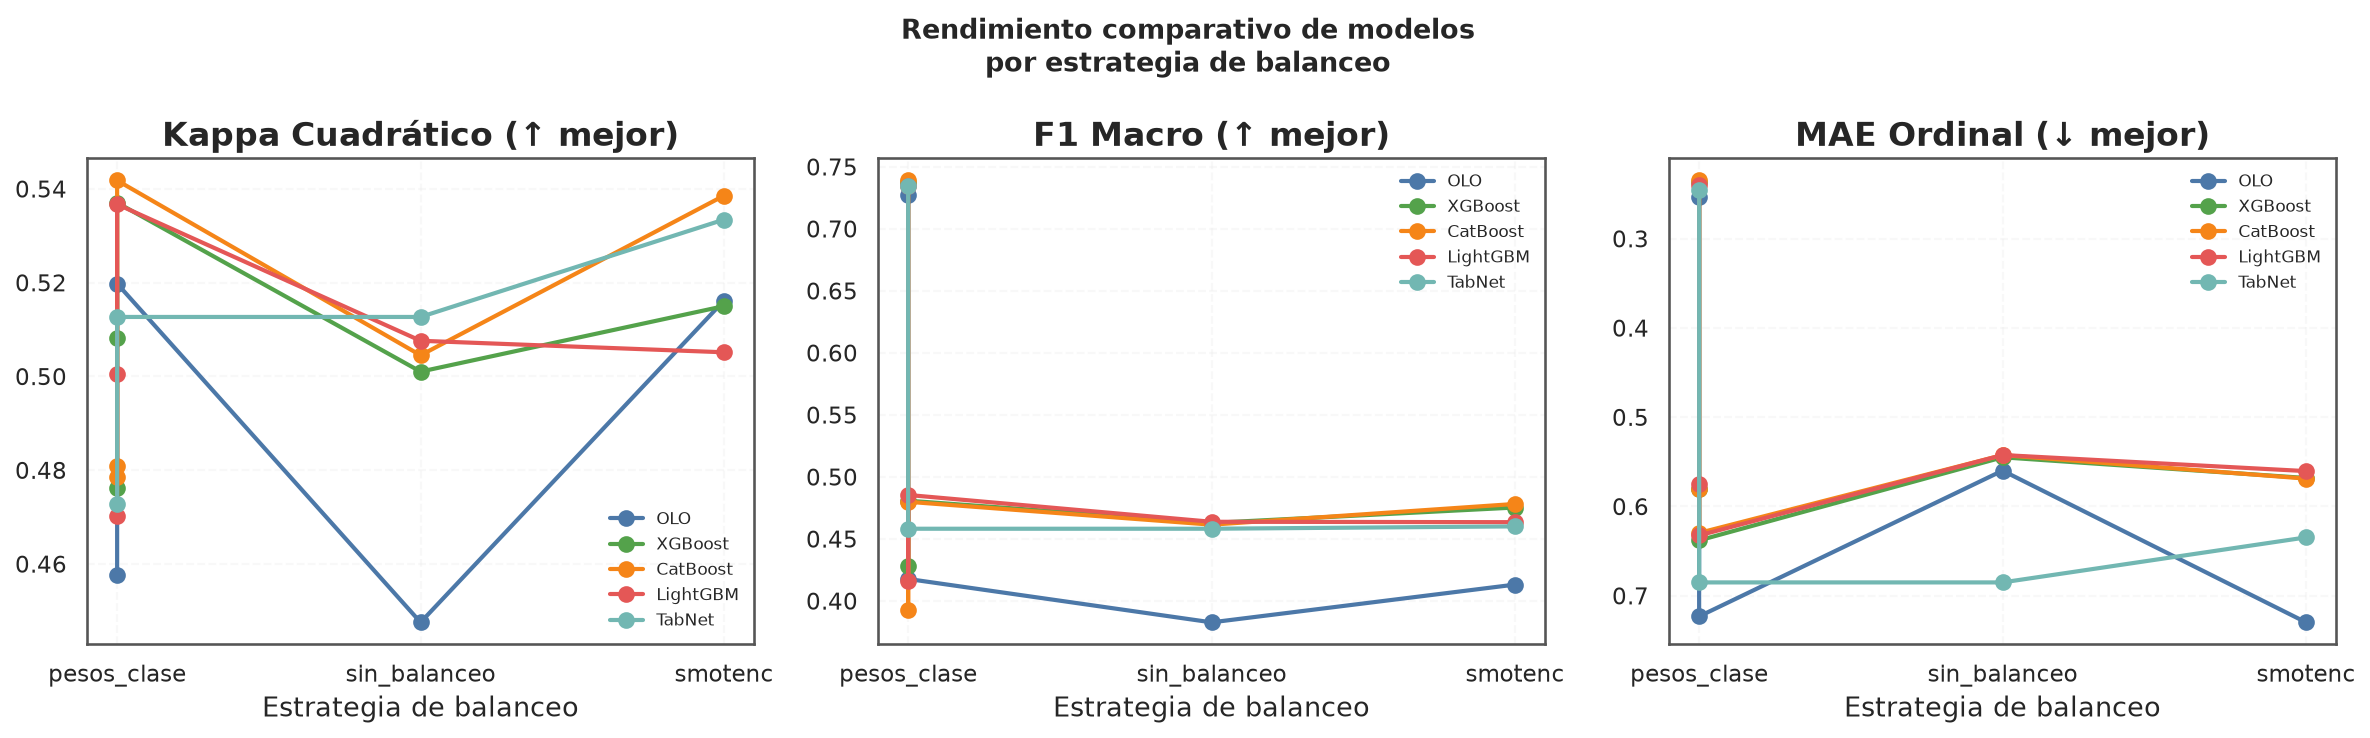

✓ Figura guardada: rendimiento_comparativo.png


In [31]:
# =============================================================================
# Gráficos de rendimiento por modelo y estrategia de balanceo
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Rendimiento comparativo de modelos\npor estrategia de balanceo",
    fontsize=13, fontweight="bold",
)

metricas_plot = [
    ("kappa_cuadratico", "Kappa Cuadrático (↑ mejor)"),
    ("f1_macro",         "F1 Macro (↑ mejor)"),
    ("mae_ordinal",      "MAE Ordinal (↓ mejor)"),
]
modelos_orden = ["OLO", "XGBoost", "CatBoost", "LightGBM", "TabNet"]
colores_dict  = {m: THEME["models"].get(m, "#888888") for m in modelos_orden}

for ax, (metrica, titulo) in zip(axes, metricas_plot):
    for modelo in modelos_orden:
        sub = df_res[(df_res["modelo"] == modelo) & (df_res["split"] == "test")]
        if sub.empty or metrica not in sub.columns:
            continue
        ax.plot(sub["estrategia_balanceo"], sub[metrica],
                marker="o", linewidth=2, markersize=7,
                label=modelo, color=colores_dict.get(modelo, "#888888"))
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Estrategia de balanceo")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if metrica == "mae_ordinal":
        ax.invert_yaxis()

save_figure("rendimiento_comparativo")
plt.show()
print("✓ Figura guardada: rendimiento_comparativo.png")


## 22. Registro de versiones y entorno

In [32]:
# =============================================================================
# Registro de versiones para reproducibilidad
# =============================================================================
import importlib, platform, sys

libs = ["pandas","numpy","sklearn","xgboost","lightgbm",
        "catboost","pytorch_tabnet","optuna","torch","missingno","joblib"]

print(f"Fecha          : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Sistema        : {platform.system()} {platform.release()}")
print(f"Semilla global : {PARAMETERS['SEED']}")
print(f"GPU usada      : {USAR_GPU}")
print()
print("Versiones de librerías:")
for lib in libs:
    try:
        ver = getattr(importlib.import_module(lib), "__version__", "N/D")
        print(f"  {lib:<20}: {ver}")
    except ImportError:
        print(f"  {lib:<20}: NO INSTALADA")

Fecha          : 2026-07-19 19:13:15
Python         : 3.12.3
Sistema        : Linux 6.17.0-35-generic
Semilla global : 42
GPU usada      : True

Versiones de librerías:
  pandas              : 3.0.3
  numpy               : 2.4.6
  sklearn             : 1.9.0
  xgboost             : 3.3.0
  lightgbm            : 4.6.0
  catboost            : 1.2.10
  pytorch_tabnet      : N/D
  optuna              : 4.9.0
  torch               : 2.13.0+cu130
  missingno           : 0.5.2
  joblib              : 1.5.3
